Подумать над переездом из колаб ради контроля версий

### импорт библиотек

In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from scipy.linalg import inv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from copy import deepcopy
from google.colab import files

In [2]:
# Установка глобальных параметров шрифта
plt.rcParams['font.size'] = 14          # Размер основного шрифта
plt.rcParams['axes.titlesize'] = 16     # Размер заголовка
plt.rcParams['axes.labelsize'] = 14     # Размер подписей осей
plt.rcParams['xtick.labelsize'] = 12    # Размер цифр на оси X
plt.rcParams['ytick.labelsize'] = 12    # Размер цифр на оси Y
plt.rcParams['legend.fontsize'] = 12    # Размер шрифта легенды

# Функции

## Data ( ***задача скорости*** )


In [3]:
"""
Перечь моих функций
def model_1_speed(x0, P0, Q, R, N=302, plot_fl=False, vybrosy=False, razbros_vybrosov=50.0, chastota_vybrosov=0.1)
def model_1_speed_nonstationary(x0, P0, Q_base, R_base, N=302,
                              plot_fl=False, plot_noise=False, vybrosy=False,
                              razbros_vybrosov=50.0,
                              chastota_vybrosov=0.1,
                              noise_variation=10,
                              noise_change_freq=30)
def model_2_angular_pos(x0, P0, Q, R, F, S, B, N, plot_fl=False, vybrosy=False, razbros_vybrosov=50.0, chastota_vybrosov=0.1)
def Kalman_filter(zs, x0, P0, F, H, Q, R, dt=0.1)
def Sage_Husa_filter(zs, x0, P0, F, H, Q, R,
                     B = np.eye(3), b = 0.998, dt=0.1, plot_qr=False)

#визуализация результатов фильтров
def print_result_filt_rmse1(true_x, true_states, y_measure, fil_states)
def plot_results(true_x, true_states, filtered_states, measurements, covariances=None, dt=0.1)
def calculate_rmse(true_x, true_states, filtered_states)
def print_rmse_results(true_x, true_states, xs, zs)

# ENN
def result_enn_rmse(true_x, true_states, y_measure,
                    fil_states, predictions, y_cec, Q_new, R_new, num_xi = 1, fl_train=True)
class SequenceRNN(nn.Module)

# Тест
def rmse_in_time(y1, y2)
def plot_1seq(x_plot, dt = 0.1)
"""

'\nПеречь моих функций\ndef model_1_speed(x0, P0, Q, R, N=302, plot_fl=False, vybrosy=False, razbros_vybrosov=50.0, chastota_vybrosov=0.1)\ndef model_1_speed_nonstationary(x0, P0, Q_base, R_base, N=302,\n                              plot_fl=False, plot_noise=False, vybrosy=False,\n                              razbros_vybrosov=50.0,\n                              chastota_vybrosov=0.1,\n                              noise_variation=10,\n                              noise_change_freq=30)\ndef model_2_angular_pos(x0, P0, Q, R, F, S, B, N, plot_fl=False, vybrosy=False, razbros_vybrosov=50.0, chastota_vybrosov=0.1)\ndef Kalman_filter(zs, x0, P0, F, H, Q, R, dt=0.1)\ndef Sage_Husa_filter(zs, x0, P0, F, H, Q, R,\n                     B = np.eye(3), b = 0.998, dt=0.1, plot_qr=False)\n\n#визуализация результатов фильтров\ndef print_result_filt_rmse1(true_x, true_states, y_measure, fil_states)\ndef plot_results(true_x, true_states, filtered_states, measurements, covariances=None, dt=0.1)\ndef

In [4]:
def model_1_speed(x0, P0, Q, R, N=302, plot_fl=False, vybrosy=False, razbros_vybrosov=50.0, chastota_vybrosov=0.1):
    # Размерности
    n = P0.shape[1]  # =3 (размерность состояния)
    m = R.shape[1]   # = (размерность измерения)
    p = Q.shape[1]   # =3 (размерность шума процесса)

    # Векторы шумов (нулевое среднее)
    w0 = np.zeros(p)
    v0 = np.zeros(m) # Если m > 1, v будет вектором
    y = np.zeros((N*m, 1)) # Выходной сигнал

    # Параметры модели
    T = 0.1     # Шаг дискретизации

    # Генерация начального состояния (с учётом P0)
    X = multivariate_normal.rvs(x0, P0) # Состояние с учетом начальной неопределенности
    x_true_val = x0 # Истинное состояние, начинаем точно с x0

    F = np.array([[1, T, (T**2)/2],
                  [0, 1, T],
                  [0, 0, 1]])

    # Массивы для хранения истории состояний и истинного значения
    states_history = np.zeros((N, n))
    x_true_arr = np.zeros((N,n))

    # Моделирование на N шагов
    for j in range(N):
        w = multivariate_normal.rvs(w0, Q) # Шум процесса
        v = multivariate_normal.rvs(v0, R) # Шум измерений

        # Уравнение состояния для истинного значения (без шума процесса)
        x_true_val = F @ x_true_val
        x_true_arr[j] = x_true_val

        # Уравнение состояния для смоделированного значения (с шумом процесса)
        X = F @ X + w

        # Сохраняем состояние
        states_history[j] = X

        # Выход (измерение: вторая компонента состояния + шум измерений)
        # Примечание: Если m > 1, X[1] (скаляр) будет добавлен к каждой компоненте вектора v.
        current_measurement = X[1] + v

        # Добавление выбросов, если включено
        if vybrosy:
            # Генерируем случайное число от 0 до 1. Если оно меньше chastota_vybrosov, добавляем выброс.
            if np.random.rand() < chastota_vybrosov:
                # Генерируем выброс из нормального распределения с нулевым средним
                current_measurement += multivariate_normal.rvs(0, razbros_vybrosov)

        # Выход
        y[j*m:(j+1)*m, 0] = current_measurement



    if plot_fl:
        time = np.arange(N) * dt

        plt.figure(figsize=(12, 9))
        # График всех компонент состояния вместе
        plt.subplot(2, 2, 1)
        plt.plot(time, states_history[:, 0], label='Position (x1)')
        plt.plot(time, y, label='Velocity y - result')
        plt.plot(time, states_history[:, 2], label='Acceleration (x3)')
        plt.title('All State Components')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

        # Графики компонент по отдельности
        plt.subplot(2, 2, 2)
        plt.plot(time, states_history[:, 0], 'r')
        plt.plot(time, x_true_arr[:, 0], 'g')
        plt.title('Position (x1)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 3)
        plt.plot(time, y, 'r')
        plt.plot(time, x_true_arr[:, 1], 'g')
        plt.title('Velocity y - result')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 4)
        plt.plot(time, states_history[:, 2], 'r')
        plt.plot(time, x_true_arr[:, 2], 'g')
        plt.title('Acceleration (x3)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.tight_layout()
        plt.show()


    return x_true_arr, states_history, y

In [5]:
def model_1_speed_nonstationary(x0, P0, Q_base, R_base, N=302,
                              plot_fl=False, plot_noise=False, vybrosy=False,
                              razbros_vybrosov=50.0,
                              chastota_vybrosov=0.1,
                              noise_variation=10,
                              noise_change_freq=30):
    """
    Генерация данных с нестационарными шумами для тестирования Sage-Husa

    Параметры:
        x0, P0: начальное состояние и ковариация
        Q_base, R_base: базовые ковариации шумов процесса и измерений
        N: количество шагов
        noise_variation: степень изменения шумов (0-1)
        noise_change_freq: частота изменения параметров шума (в шагах)
        ... остальные параметры как в оригинальной функции
    """
    n = P0.shape[1]  # Размерность состояния
    m = R_base.shape[1]  # Размерность измерения
    p = Q_base.shape[1]  # Размерность шума процесса

    # Инициализация
    y = np.zeros((N*m, 1))
    states_history = np.zeros((N, n))
    x_true_arr = np.zeros((N, n))
    x_true_val = x0
    X = multivariate_normal.rvs(x0, P0)
    T = 0.1

    F = np.array([[1, T, (T**2)/2],
                  [0, 1, T],
                  [0, 0, 1]])

    # Матрицы для хранения изменяющихся шумов
    Q_history = np.zeros((N, p, p))
    R_history = np.zeros((N, m, m))

    for j in range(N):
        # Генерация нестационарных шумов
        if j % noise_change_freq == 0:
            # Изменение шума процесса
            Q_factor = abs(1 + noise_variation * (2*np.random.rand() - 1))
            Q = Q_base * Q_factor

            # Изменение шума измерений (может быть разным для разных компонент)
            R_factor = abs(np.diag(1 + noise_variation * (2*np.random.rand(m) - 1)))
            R = R_base @ R_factor

        # Сохраняем текущие параметры шумов
        Q_history[j] = Q
        R_history[j] = R

        # Генерация шумов
        w = multivariate_normal.rvs(np.zeros(p), Q)
        v = multivariate_normal.rvs(np.zeros(m), R)

        # Обновление состояния
        x_true_val = F @ x_true_val
        x_true_arr[j] = x_true_val
        X = F @ X + w

        states_history[j] = X

        # Измерение с нестационарным шумом
        current_measurement = X[1] + v

        if vybrosy and (np.random.rand() < chastota_vybrosov):
            current_measurement += multivariate_normal.rvs(0, razbros_vybrosov)

        y[j*m:(j+1)*m, 0] = current_measurement

    # Визуализация параметров шумов
    if plot_noise:
        plt.figure(figsize=(12, 6))
        plt.subplot(2,1,1)
        plt.plot(Q_history[:,0,0], label='Q (1,1))')
        plt.plot(Q_history[:,1,1], label='Q (2,2)')
        plt.plot(Q_history[:,2,2], label='Q (3,3)')
        plt.title('Изменение параметров шума процесса')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(R_history[:,0,0], label='R variation')
        plt.title('Изменение параметров шума измерений')
        plt.legend()
        plt.tight_layout()


    if plot_fl:
        time = np.arange(N) * dt

        plt.figure(figsize=(12, 9))
        # График всех компонент состояния вместе
        plt.subplot(2, 2, 1)
        plt.plot(time, states_history[:, 0], label='Position (x1)')
        plt.plot(time, y, label='Velocity y - result')
        plt.plot(time, states_history[:, 2], label='Acceleration (x3)')
        plt.title('All State Components')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

        # Графики компонент по отдельности
        plt.subplot(2, 2, 2)
        plt.plot(time, states_history[:, 0], 'r')
        plt.plot(time, x_true_arr[:, 0], 'g')
        plt.title('Position (x1)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 3)
        plt.plot(time, y, 'r')
        plt.plot(time, x_true_arr[:, 1], 'g')
        plt.title('Velocity y - result')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 4)
        plt.plot(time, states_history[:, 2], 'r')
        plt.plot(time, x_true_arr[:, 2], 'g')
        plt.title('Acceleration (x3)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return x_true_arr, states_history, y #, Q_history, R_history

In [6]:
"""
#добавление выбросов:
y_measure12 = y_measure1.copy()
for i in range(all_seq_s):
  for j in range(N):
    if np.random.rand() < 0.1:
      y_measure12[i][j][0] += multivariate_normal.rvs(0, 50)
"""

'\n#добавление выбросов:\ny_measure12 = y_measure1.copy()\nfor i in range(all_seq_s):\n  for j in range(N):\n    if np.random.rand() < 0.1:\n      y_measure12[i][j][0] += multivariate_normal.rvs(0, 50)\n'

## Data (задача №2)

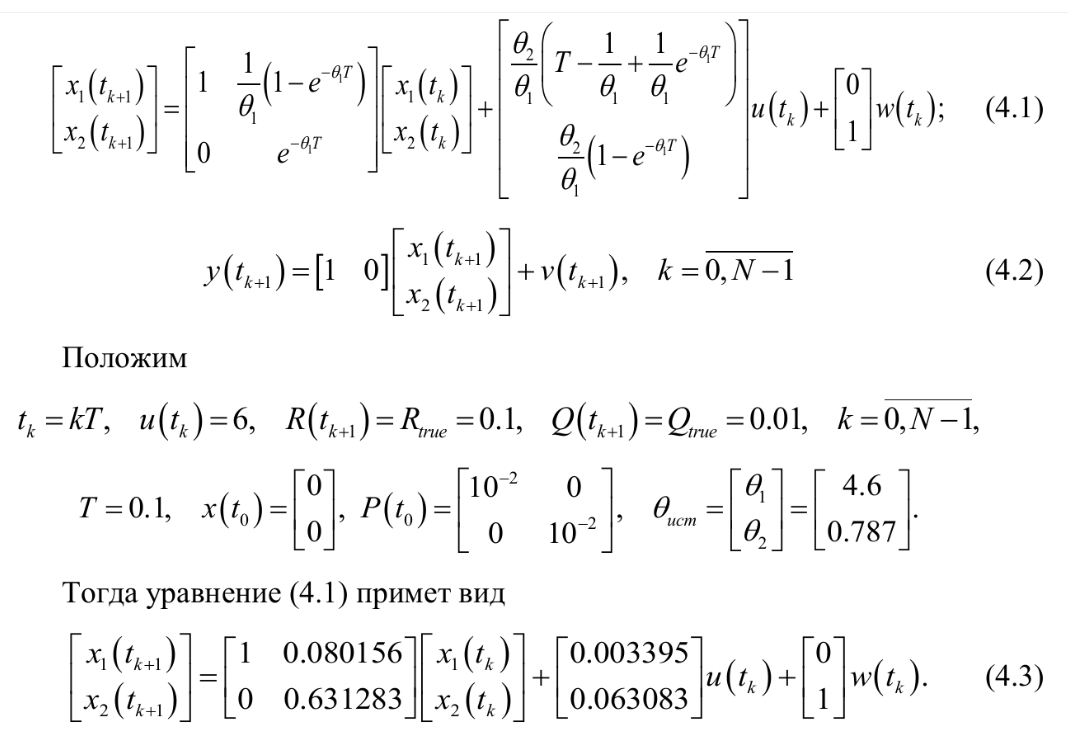

In [7]:
def plot_model2_results(states_history, x_true_arr, y, N, T=0.1):
    """Визуализация результатов моделирования"""
    time = np.arange(N) * T

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # График 1: Угловое положение (x1)
    axes[0, 0].plot(time, states_history[:, 0], 'b-', alpha=0.7, label='Модель с шумом')
    axes[0, 0].plot(time, x_true_arr[:, 0], 'g-', label='Истинное значение')
    axes[0, 0].set_title('Угловое положение (x1)')
    axes[0, 0].set_xlabel('Время')
    axes[0, 0].set_ylabel('Значение')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # График 2: Угловая скорость (x2)
    axes[0, 1].plot(time, states_history[:, 1], 'b-', alpha=0.7, label='Модель с шумом')
    axes[0, 1].plot(time, x_true_arr[:, 1], 'g-', label='Истинное значение')
    axes[0, 1].set_title('Угловая скорость (x2)')
    axes[0, 1].set_xlabel('Время')
    axes[0, 1].set_ylabel('Значение')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # График 3: Измерения
    axes[1, 0].plot(time, y, 'r-', alpha=0.7, label='Измерения')
    axes[1, 0].plot(time, x_true_arr[:, 0], 'g-', label='Истинное значение')
    axes[1, 0].set_title('Измерения углового положения')
    axes[1, 0].set_xlabel('Время')
    axes[1, 0].set_ylabel('Значение')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # График 4: Шумы
    axes[1, 1].plot(time, states_history[:, 0] - x_true_arr[:, 0], 'orange', label='Ошибка состояния')
    axes[1, 1].plot(time, y[:,0] - x_true_arr[:, 0], 'purple', alpha=0.7, label='Ошибка измерений')
    axes[1, 1].set_title('Ошибки модели для х1 - положения')
    axes[1, 1].set_xlabel('Время')
    axes[1, 1].set_ylabel('Ошибка')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
def model_2_angular_pos(x0, P0, Q, R, F, S, Ge, N, plot_fl=False, vybrosy=False,
                       razbros_vybrosov=50.0, chastota_vybrosov=0.1):
    """
    Генерация данных для системы с шумами

    Parameters:
    x0 : array_like - начальное матожидание состояния
    P0 : array_like - начальная ковариационная матрица состояния
    Q : float - дисперсия шума процесса
    R : float - дисперсия шума измерений
    F : array_like - матрица перехода состояния
    S : array_like - вектор управления
    B : array_like - вектор шума процесса
    N : int - количество шагов
    """
    # Размерности
    n = P0.shape[0]  # размерность состояния (2)
    S = S.reshape(n)

    # Генерация шумов
    #w = np.random.normal(0, Q, (N, 1))  # шум процесса
    #v = np.random.normal(0, R, (N, 1))  # шум измерений

    w = np.random.multivariate_normal(np.array([0]), Q, N)  # шум процесса
    v = np.random.multivariate_normal(np.array([0]), R, N)  # шум измерений

    # Инициализация массивов
    states_history = np.zeros((N, n))
    x_true_arr = np.zeros((N, n))
    y = np.zeros((N,1))

    # Начальное состояние - случайное из распределения N(x0, P0)
    X_current = x0 #np.random.multivariate_normal(x0, P0) #.reshape(-1, 1)

    for j in range(N):
        # ИСТИННОЕ состояние (без шума процесса)
        # При нулевом шаге = мат ожиданию np.zeros(n)
        x_true_val = F @ x_true_arr[j-1] + S * 6 if j > 0 else x0
        x_true_arr[j] = x_true_val

        # РЕАЛЬНОЕ состояние (с шумом процесса)
        X_current = F @ X_current + S * 6 + Ge @ w[j] #.reshape(-1, 1)
        states_history[j] = X_current

        # Измерение (первая компонента + шум измерений)
        current_measurement = X_current[0] + v[j]

        # Добавление выбросов
        if vybrosy and np.random.rand() < chastota_vybrosov:
            current_measurement += np.random.normal(0, razbros_vybrosov)

        y[j] = current_measurement

    if plot_fl:
        plot_model2_results(states_history, x_true_arr, y, N)

    return x_true_arr, states_history, y

## Фильтры




In [9]:
# Фильтр Калмана
def Kalman_filter(zs, x0, P0, F, H, Q, R, Ge, dt=0.1, Ksi_U = np.array([0])):
  dim = x0.shape[0]
  x=np.reshape(x0, (dim,1))

  if Ksi_U.all() == 0:  # !!! Пропускает если первый элем = 0
    Ksi_U = np.zeros(x.shape)

  xf = []
  #cov = []

  P=P0.copy()
  for z in zs:
      # predict
      x = F @ x + Ksi_U
      P = F @ P @ F.T + Ge @ Q @ Ge.T

      #update
      S = H @ P @ H.T + R
      K = P @ H.T @ inv(S)
      epsi = z - H @ x
      x += K @ epsi
      P = P - K @ H @ P

      xf.append(x.reshape(dim))
      #cov.append(P)
  return xf #, cov

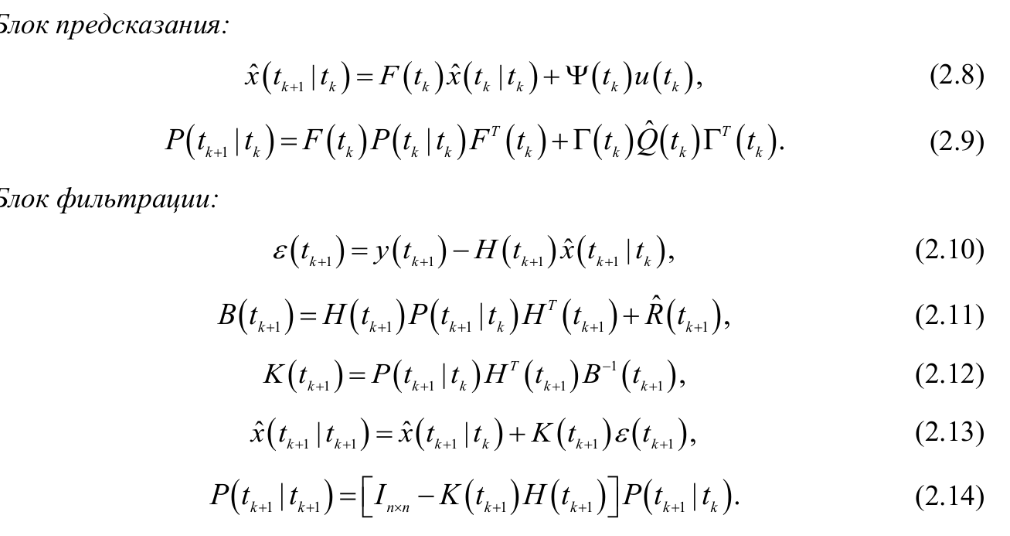

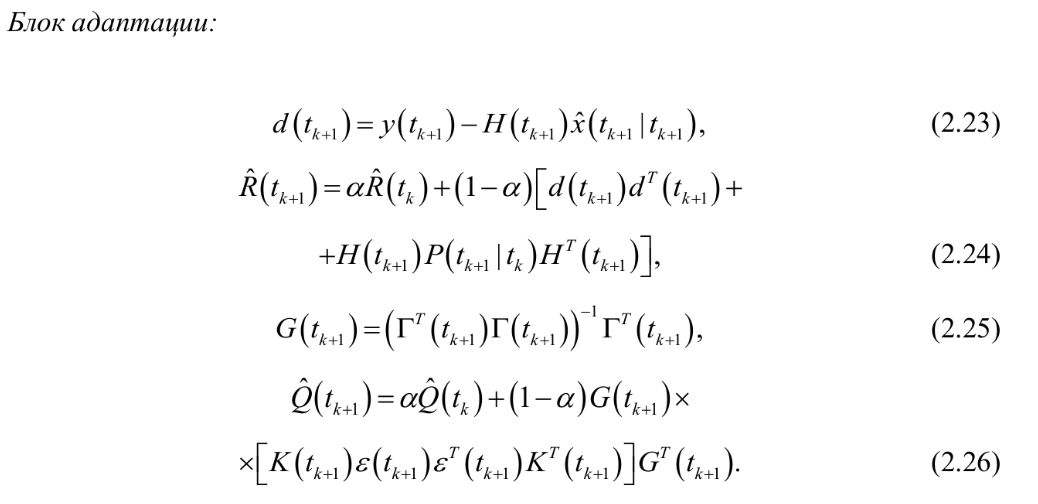

In [10]:
def Ahlagi_Zhou_Huang_filter(zs, x0, P0, F, H, Q, R, Ge, alpha, Ksi_U = np.array([0]), dt=0.1, plot_qr=False):
  dim = x0.shape[0]
  x=np.reshape(x0, (dim,1))
  if Ksi_U.all() == 0: # !!! Пропускает если первый элем = 0
    #print("Ksi_U not define. Ksi_U = np.zeros(", x.shape, ")")
    Ksi_U = np.zeros(x.shape)

  N = zs.shape[0]
  P = P0.copy()
  Qs = Q.copy()
  Rs = R.copy()

  arr_Q = np.zeros((N, Q.shape[0], Q.shape[0]))
  arr_R = np.zeros((N, 1, 1))
  xf_filt = []
  t=0

  for z in zs:
      arr_Q[t] = Qs
      arr_R[t] = Rs

      # predict
      x2 = F @ x + Ksi_U #Psi @ u
      P2 = F @ P @ F.T + Ge @ Qs @ Ge.T

      #update
      S = H @ P2 @ H.T + Rs
      K = P2 @ H.T @ inv(S)
      epsi = z - H @ x2
      x =x2 + K @ epsi
      P = P2 - K @ H @ P2

      #adaptation
      d = (z - H @ x) #[:, np.newaxis] #бред
      Rs = alpha * Rs + (1 - alpha) * (d @ d.T + H @ P2 @ H.T)

      G = inv(Ge.T @ Ge) @ Ge.T
      Qs = alpha * Qs + (1 - alpha) * (G @ (K @ epsi @ epsi.T @ K.T) @ G.T)

      t+=1

      xf_filt.append(np.reshape(x, (dim)))

  if plot_qr:
    fig, axs = plt.subplots(1, 2, figsize=(15, 10))
    fig.suptitle('Анализ параметров фильтра Ахлаги...', fontsize=16)
    for i in range(dim):
        axs[1, 0].plot(arr_Q[:, i, i], label=f'Q[{i},{i}]')
    axs[1, 0].set_title('Диагональные элементы Q (ковариация процессного шума)')
    axs[1, 0].set_xlabel('Временной шаг')
    axs[1, 0].set_ylabel('Значение')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    axs[1, 1].plot(arr_R[:, 0], 'm-', label='R')
    axs[1, 1].set_title('Скаляр R (ковариация шума измерений)')
    axs[1, 1].set_xlabel('Временной шаг')
    axs[1, 1].set_ylabel('Значение')
    axs[1, 1].legend()
    axs[1, 1].grid(True)
    plt.tight_layout()
    plt.show()

    # Отдельный график для всех компонент arr_Q
    plt.figure(figsize=(14, 8))
    colors = plt.cm.tab10.colors
    for i in range(dim):
        for j in range(dim):
            plt.plot(arr_Q[:, i, j],
                    color=colors[i*dim + j],
                    linestyle='-',
                    linewidth=1.5,
                    label=f'Q[{i},{j}]')

    plt.title('Все компоненты матрицы Q (ковариация процессного шума)', fontsize=14)
    plt.xlabel('Временной шаг', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1),
              loc='upper left',
              borderaxespad=0.,
              fontsize=10)
    plt.tight_layout()
    plt.show()

  return xf_filt



## визуал rmse фильтров

In [11]:
def calculate_ARMSE_scratch(true_states, fil_states, M, N, x_dim):
    total_squared_errors = 0

    for i in range(M):          # для каждого запуска
        for j in range(N):      # для каждого временного шага
            for k in range(x_dim):  # для каждой компоненты состояния
                error = true_states[i, j, k] - fil_states[i, j, k]
                total_squared_errors += error**2

    # ARMSE = sqrt(1/(M*N) * сумма всех квадратов ошибок)
    ARMSE = np.sqrt(total_squared_errors / (M * N))

    return ARMSE

In [12]:
def calculate_ARMSE_n_dim(true_states, fil_states):
    errors = true_states - fil_states  # форма: (M, N, x_dim)

    armse_i = np.sqrt(np.mean(errors**2, axis=(0, 1)))

    ARMSE = np.linalg.norm(armse_i)  # √(Σ ARMSE_i²)

    return ARMSE

def print_result_filt_ARMSE(true_x, true_states, y_measure, fil_states, num_Xi):

    M = true_x.shape[0]
    N = true_x.shape[1]
    x_dim = true_x.shape[-1]

    err_true = calculate_ARMSE_n_dim(true_x[:, :, num_Xi], fil_states[:, :, num_Xi])
    err_state = calculate_ARMSE_n_dim(true_states[:, :, num_Xi], fil_states[:, :, num_Xi])

    #err_Milutin = calculate_ARMSE_n_dim(y_measure[:, :, num_Xi], fil_states[:, :, num_Xi])

    print("True x & Filt x:                {:.4f}".format(err_true))
    #print("Milutin Noise & Filt:           {:.4f}".format(err_Milutin))
    print("State x & Filt x:               {:.4f}".format(err_state))

    return err_true, err_state


In [13]:
def print_result_filt_rmse(true_x, true_states, y_measure,
                    fil_states, num_Xi):
    print("\nRMSE компоненты скорости:")

    # Вычисляем ошибки
    e1 = np.sqrt(mean_squared_error(true_x[:, :, num_Xi], y_measure[:, :, 0]))
    e2 = np.sqrt(mean_squared_error(true_x[:, :, num_Xi], true_states[:, :, num_Xi]))
    e3 = np.sqrt(mean_squared_error(true_x[:, :, num_Xi], fil_states[:, :, num_Xi]))

    # Форматируем вывод с выравниванием
    print("True x & Measure y:        {:.4f}".format(e1))
    print("True x & Noise state x:    {:.4f}".format(e2))
    print("True x & Filter x:         {:.4f}".format(e3))

    e2 = np.sqrt(mean_squared_error(true_states[:, :, num_Xi], fil_states[:, :, 0]))
    e3 = np.sqrt(mean_squared_error(y_measure[:, :, 0], fil_states[:, :, 1]))

    #print("Noise state x & Measure y: {:.4f}".format(e2))
    print("y_measure x & Filter x:  {:.4f}".format(e3))

### Визуал 2d/3d

In [14]:
def plot_results2(true_x, true_states, filtered_states, measurements, covariances=None, dt=0.1):
    """Visualize the filtering results for 2 dim X."""
    time = np.arange(len(true_states)) * dt

    plt.figure(figsize=(12, 9))

    # Plot position
    plt.subplot(4, 1, 1)
    plt.plot(time, true_x[:, 0], 'g-', label='Истинная позиция')
    plt.plot(time, filtered_states[:, 0], 'b-', label='Отфильтрованная')
    plt.plot(time, measurements, 'r-', alpha=0.5, label='y - с шумом измерения')

    plt.ylabel('Position (m)')
    plt.title('Позиция')
    plt.legend()
    plt.grid(True)

    # Plot velocity
    plt.subplot(4, 1, 2)
    plt.plot(time, true_x[:, 1], 'g-', label='Истинная скорость')
    plt.plot(time, true_states[:, 1], 'r-', label='Зашум. скорость')
    plt.plot(time, filtered_states[:, 1], 'b-', label='Отфильтрованная')

    plt.ylabel('Velocity (m/s)')
    plt.xlabel('Time (s)')
    plt.title('Скорость')
    plt.legend()
    plt.grid(True)

    plt.subplot(4, 1, 3)
    plt.plot(time, true_states[:, 0] - filtered_states[:, 0], 'r-', label='Position Error')
    plt.plot(time, true_states[:, 1] - filtered_states[:, 1], 'g-', label='Velocity Error')
    plt.title('Разность между зашум. состоянием x и отфильтрованным')
    plt.ylabel('Error')
    plt.xlabel('Time (s)')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()


In [15]:
def plot_filt_results3(true_x, true_states, filtered_states, measurements, covariances=None, dt=0.1):
    """Visualize the filtering results for 3 dim X."""
    time = np.arange(len(true_states)) * dt

    plt.figure(figsize=(12, 9))

    # Plot position
    plt.subplot(4, 1, 1)
    plt.plot(time, true_x[:, 0], 'g-', label='Истинная позиция')
    plt.plot(time, true_states[:, 0], 'r-', label='Зашум. позиция')
    plt.plot(time, filtered_states[:, 0], 'b-', label='Отфильтрованная')
    plt.ylabel('Position (m)')
    plt.title('Позиция')
    plt.legend()
    plt.grid(True)

    # Plot velocity
    plt.subplot(4, 1, 2)
    plt.plot(time, true_x[:, 1], 'g-', label='Истинная скорость')
    plt.plot(time, measurements, 'r-', alpha=0.5, label='Скорость y с шумом измерения')
    plt.plot(time, filtered_states[:, 1], 'b-', label='Отфильтрованная')

    # Plot 3σ confidence interval
    #std = np.sqrt(covariances[:, 1, 1])
    #plt.fill_between(time,
                    #filtered_states[:, 1] - 3*std,
                    #filtered_states[:, 1] + 3*std,
                    #color='b', alpha=0.1, label='3σ confidence')
    plt.ylabel('Velocity (m/s)')
    plt.xlabel('Time (s)')
    plt.title('Скорость')
    plt.legend()
    plt.grid(True)

    # Plot acceleration
    plt.subplot(4, 1, 3)
    plt.plot(time, true_x[:, 2], 'g-', label='Истинное ускорение')
    plt.plot(time, true_states[:, 2], 'r-', alpha=0.5, label='Зашум. ускорение')
    plt.plot(time, filtered_states[:, 2], 'b-', label='Отфильтрованное')
    plt.ylabel('Acceleration')
    plt.xlabel('Time (s)')
    plt.title('Ускорение')
    plt.legend()
    plt.grid(True)

    plt.subplot(4, 1, 4)
    plt.plot(time, true_states[:, 0] - filtered_states[:, 0], 'r-', label='Position Error')
    plt.plot(time, true_states[:, 1] - filtered_states[:, 1], 'g-', label='Velocity Error')
    plt.plot(time, true_states[:, 2] - filtered_states[:, 2], 'b-', label='Acceleration Error')
    plt.title('Разность между зашум. состоянием x и отфильтрованным')
    plt.ylabel('Error')
    plt.xlabel('Time (s)')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()


## ENN & rmse

У нас есть:
- x_true (24, 302, 3)
- x_noise (24, 302, 3)
- y_measure1 (24, 302, 1)
- x_kalman,x_sage_husa (24, 302, 3)

Также (это компоненты скорости):
- y_mc = y_measure1[1:-1]
- y_ec = x_sage_husa[2:]
- y_ec1 = x_sage_husa[1:-1]
- y_ec2 = x_sage_husa[:-2]
- y_c = x_noise[2:]

In [16]:
def result_enn_rmse(true_x, true_states, y_measure,
                    fil_states, predictions, y_cec, Q_new, R_new, num_xi = 1, fl_train=True, Ksi_U = np.zeros(1), Ge = np.zeros(1)):
  if np.all(Ksi_U == 0):
      Ksi_U = np.zeros(x0.shape)
  if np.all(Ge == 0):
      Ge = np.eye(dim_X)

  y_enn = predictions + y_cec[:,:,1]
  x_start = true_x.shape[1] - y_enn.shape[1]
  end = true_x.shape[0]
  st = end-y_enn.shape[0]
  if fl_train:
    st = 0
    end = y_enn.shape[0]
  e1 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], true_states[st:end, x_start:, num_xi]))
  e2 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e3 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], fil_states[st:end, x_start:, num_xi]))
  e4 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], y_enn))

  j = end-st
  Xkalman = np.zeros((j, y_enn.shape[1], true_x.shape[2]))
  j=0
  for i in range(st, end):
    xf = Kalman_filter(y_measure1[i, x_start:], x0, P0, F, H, Q_new, R_new, Ksi_U=Ksi_U, Ge=Ge)
    Xkalman[j] = xf
    j+=1

  e5 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], Xkalman[:, :, num_xi]))
  print('\n', true_x[st:end, 2:, num_xi].shape)
  print("True Vs Measure y    ", e2)
  #print("True Vs State X      ", e1)
  print("True Vs AKF        ", e3)
  print("True Vs Kalman     ", e5)
  print("True Vs ENN          ", e4)
  rmse_row1 = [e2, e5, e3, e4]

  e1 = np.sqrt(mean_squared_error(fil_states[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e2 = np.sqrt(mean_squared_error(y_enn, y_measure[st:end, x_start:, 0]))
  e3 = np.sqrt(mean_squared_error(Xkalman[:, :, 1], y_measure[st:end, x_start:, 0]))
  #print("\nMeasure y Vs Kalman      ", e3)
  #print("Measure y Vs AKF      ", e1)
  #print("Measure y Vs ENN      ", e2)
  rmse_row2 = [e3, e1, e2]
  e2 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e3 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], fil_states[st:end, x_start:, num_xi]))
  e4 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], y_enn))
  e5 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], Xkalman[:, :, num_xi]))
  #print("\nState X Vs Measure y    ", e2)
  #print("State X Vs AKF     ", e3)
  #print("State X Vs Kalman     ", e5)
  #print("State X Vs ENN          ", e4)

  return y_enn, rmse_row1, rmse_row2

In [17]:
class SequenceRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(SequenceRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                         batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)  # Каждый шаг → 1 число

    def forward(self, x):
        # x shape: (batch_size, 300, 3)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)  # out shape: (batch_size, 300, hidden_size)
        out = self.fc(out)  # shape: (batch_size, 300, 1)
        return out
    def predict(self, x):
        # Переводим модель в режим оценки
        self.eval()

        # Автоматическое преобразование входных данных
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)

        # Добавляем размерность батча если нужно
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # Вычисление предсказания без вычисления градиентов
        with torch.no_grad():
            prediction = self.forward(x)

        return prediction.squeeze().numpy()  # Возвращаем numpy array

## Тест

In [18]:
def rmse_in_time(y1, y2):
  return np.sqrt((((y1 - y2)**2).sum(axis=0)) / y1.shape[0])

In [19]:
# функция для визуализации одной последовательности из n компонент
def plot_1seq_MY(x_plot, dt = 0.1):
        N = x_plot.shape[0]
        time = np.arange(N) * dt
        for i in range(x_plot.shape[1]):
          plt.figure(figsize=(12, 9))
          # График всех компонент состояния вместе
          plt.subplot(2, 2, i+1)
          plt.plot(time, x_plot[:, i], 'g')
          plt.title(f'(x{i})')
          plt.xlabel('Time')
          plt.ylabel('Value')
          plt.grid(True)

        plt.tight_layout()
        plt.show()

In [20]:
def plot_1seq(x_plot, dt=0.1):
    """
    Визуализирует n-компонентную последовательность

    Parameters:
    x_plot : numpy.ndarray
        Массив формы (N, n_components) с n компонентами
    dt : float, optional
        Временной шаг, по умолчанию 0.1
    """
    N, n_components = x_plot.shape

    # Автоматически определяем размер сетки графиков
    if n_components <= 3:
        n_rows = n_components
        n_cols = 1
    elif n_components <= 6:
        n_rows = (n_components + 1) // 2
        n_cols = 2
    else:
        n_rows = (n_components + 2) // 3
        n_cols = 3

    time = np.arange(N) * dt

    plt.figure(figsize=(4 * n_cols, 3 * n_rows))

    for i in range(n_components):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.plot(time, x_plot[:, i], 'g', linewidth=1.5)
        plt.title(f'Компонента x{i+1}')
        plt.xlabel('Время')
        plt.ylabel('Значение')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Тест задача 1

In [22]:
N = 200
all_seq_s = 15
all_seq_s2 = 10
dim_X = 3
num_Xi = 1

Q = np.diag([0.01, 0.001, 0.0001])  # Матрица ковариации шума процесса (3x3)
P0 = np.diag([0.01, 0.001, 0.0001]) # Начальная ковариация состояния (3x3)
R = np.array([[1]])        # Матрица ковариации шума измерений (3x3)
Ge = np.eye(3,3)

In [23]:
#таблицы для сохранения
columns = ['Q, R', 'Измеренный y', 'Kalman', 'Sage-Husa', 'ENN', 'train_loss', 'val_loss', 'b', 'M', 'N', 'ARMSE_orig', 'ARMSE_filt']
df_true = pd.DataFrame(columns=columns)

columns = ['Q, R', 'y&Kalman', 'y&Sage-Husa', 'y&ENN']
df_measure = pd.DataFrame(columns=columns)

## Один запуск (данные)

In [24]:
# Параметры модели
dt = 0.1
x0 = np.array([0., 0., 1.])          # Начальное состояние
F = np.array([[1., dt, (dt**2)/2],
              [0.,  1., dt],
              [0., 0., 1.]])
H = np.array([[0, 1, 0]])
Ge = np.eye(dim_X)
# Моделирование
x_true = np.zeros((all_seq_s, N, dim_X))
x_noise = np.zeros((all_seq_s, N, dim_X))
y_measure1 = np.zeros((all_seq_s, N, 1))
for i in range(all_seq_s):
  clear_x, unfil_x, zs = model_1_speed(x0, P0, Q, R, N=N)
  x_true[i, :, :] = clear_x
  x_noise[i, :, :] = unfil_x
  y_measure1[i, :, :] = zs

In [25]:
# Данные тест
x_true2 = np.zeros((all_seq_s2, N, dim_X))
x_noise2 = np.zeros((all_seq_s2, N, dim_X))
y_measure2 = np.zeros((all_seq_s2, N, 1))
for i in range(all_seq_s2):
  clear_x, unfil_x, zs = model_1_speed(x0, P0, Q, R, N=N)
  x_true2[i, :, :] = clear_x
  x_noise2[i, :, :] = unfil_x
  y_measure2[i, :, :] = zs

## Связка фильтр-enn

In [26]:
Q_new=Q/100
R_new=R/100
s_qr = 'Q100, R100'

# 1. Параметр b
best_b=0.94

b_values = np.arange(0.5, 1, 0.01)[:-1]
#b_values = np.arange(0.8, 1, 0.001)[:-1]

### Параметр b

Q_new, R_new


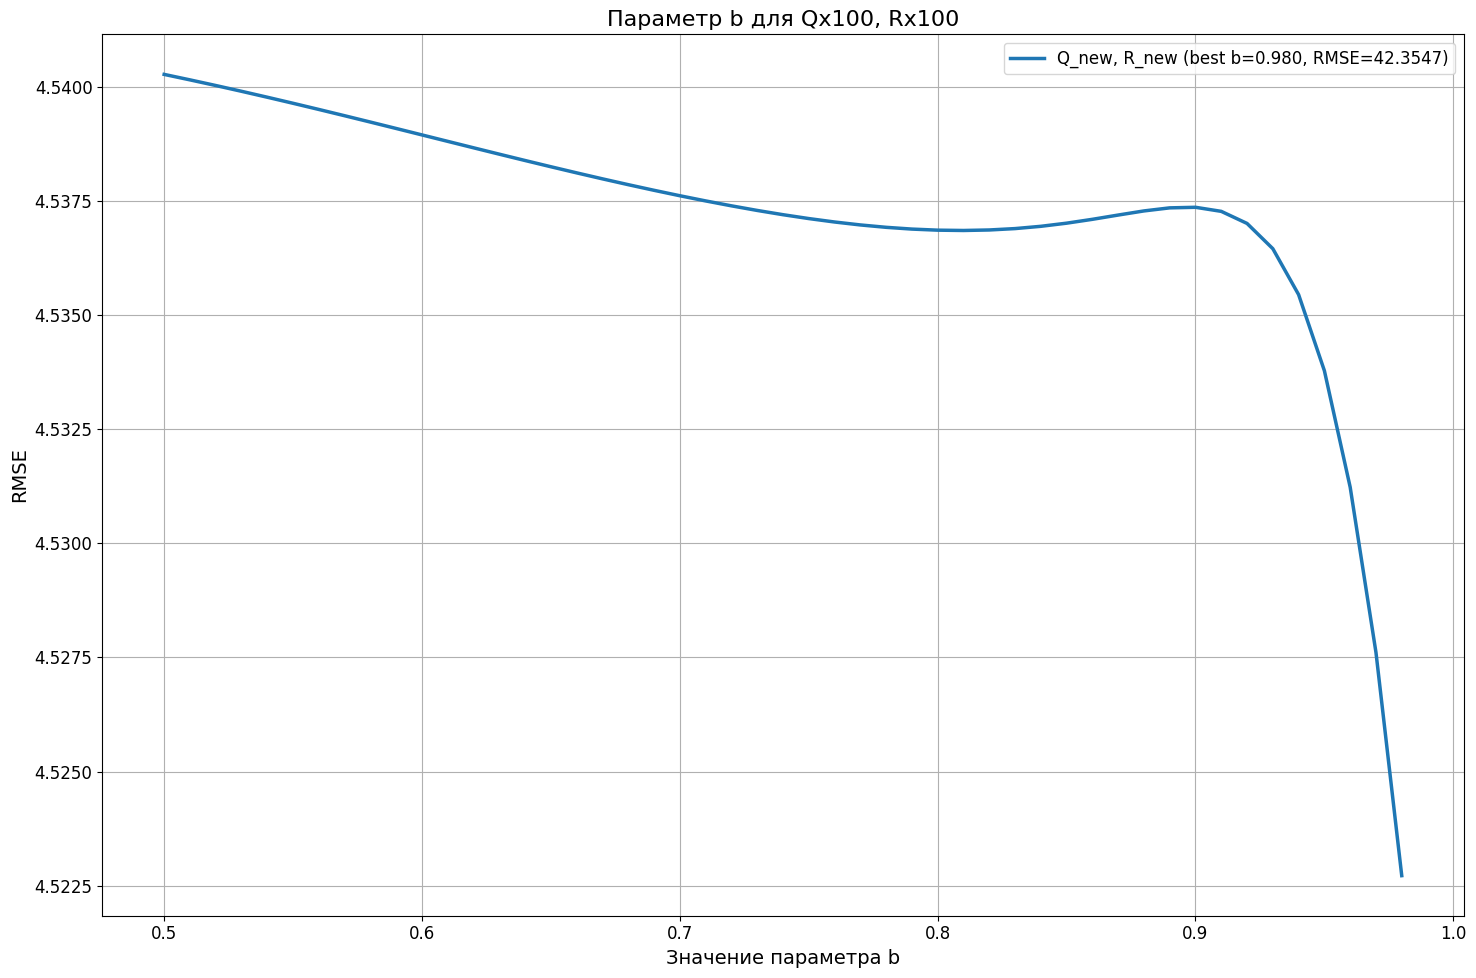


Лучшие результаты для каждой комбинации параметров:
Q_new, R_new: beta = 0.980, ARMSE = 42.3547, RMSE = 4.5227
Q_new, R_new: beta = 0.980, RMSE = 4.5227


In [ ]:
# Комбинации параметров (Q0, R0)
param_combinations = [
    ('Q_new, R_new', Q_new, R_new)
]

# Создаем фигуру для графиков
plt.figure(figsize=(15, 10))

# Словарь для хранения лучших результатов
best_results = {}
best_results_rmse = {}
best_b_rmse = 0
count = all_seq_s // 3

# Перебираем все комбинации параметров
for label, Q0, R0 in param_combinations:
    errors = []
    errors_rmse = []
    print(label)
    # Перебираем все значения b
    for b in b_values:
        x_sage_husa = np.zeros((count, N, 3))

        # Применяем фильтр для каждой последовательности
        for i in range(count):
            xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q0, R0, Ge = Ge, alpha=b)
            x_sage_husa[i] = xf

        # RMSE для компоненты
        error = np.sqrt(mean_squared_error(x_true[:count, :, num_Xi], x_sage_husa[:count, :, num_Xi]))
        errors_rmse.append(error)
        #ARMSE:
        err1 = 0
        for i in range(dim_X):
            err1 += mean_squared_error(x_true[:count, :, i], x_sage_husa[:, :, i])

        err1 = np.sqrt(err1 / dim_X)
        errors.append(err1)
        #if (b % 0.01 < 1e-6): print("b = ", round(b, 2))

    # Находим лучшее значение b для этой комбинации
    best_idx = np.argmin(errors)
    best_b = b_values[best_idx]
    best_error = errors[best_idx]
    rmse = errors_rmse[best_idx]
    best_results[label] = (best_b, best_error, rmse)

    best_idx_rmse = np.argmin(errors_rmse)
    best_b_rmse = b_values[best_idx_rmse]
    best_error_rmse = errors_rmse[best_idx_rmse]
    best_results_rmse[label] = (best_b_rmse, best_error_rmse)

    # Строим график
    plt.plot(b_values, errors_rmse, linewidth=2.5, label=f'{label} (best b={best_b:.3f}, RMSE={best_error:.4f})')

# Настройка графика
plt.title(f'Параметр b для {s_qr}')
plt.xlabel('Значение параметра b')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('b_plot.jpg', dpi=150, bbox_inches='tight')  # JPEG формат

plt.show()


# Вывод лучших результатов
print("\nЛучшие результаты для каждой комбинации параметров:")
for label, (b, error, rmse) in best_results.items():
    print(f"{label}: beta = {b:.3f}, ARMSE = {error:.4f}, RMSE = {rmse:.4f}")
    best_b = b

for label, (b, error) in best_results_rmse.items():
    print(f"{label}: beta = {b:.3f}, RMSE = {error:.4f}")
    best_b_rmse = b

### Обучение

In [27]:
#best_b = best_b_rmse

# 2. Фильтр AKF
x_sage_husa = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  # xf = Sage_Husa_filter(y_measure1[i], x0, P0, F, H, Q0, R0, B, b=best_b)
  xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge=Ge, alpha=best_b)
  x_sage_husa[i] = xf

x_kalman = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  xf = Kalman_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge=Ge)
  x_kalman[i] = xf

print("Фильтр Калмана: ")
print_result_filt_rmse(x_true, x_noise, y_measure1, x_kalman, num_Xi)
print("\nФильтр AKF: ")
print_result_filt_rmse(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)

print("\nARMSE Фильтр Калмана: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_kalman, num_Xi)
print("\nARMSE Фильтр AKF: ")
armse_orig, armse_filt = print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)


# Формируем выборки
y_mc = y_measure1[:, 1:-1, 0]
y_ec1 = x_sage_husa[:, 1:-1, 1]
y_ec2 = x_sage_husa[:, :-2, 1]
y_ec = x_sage_husa[:, 2:, 1]
y_c = x_true[:, 2:, 1]

merge_model = np.stack([y_mc, y_ec1, y_ec2], axis=2)

y_c_ec = np.stack([y_c, y_ec], axis=2)
y_c_ec = np.stack([y_c, y_ec], axis=2)

X_train, X_val, y_cec_train, y_cec_val = train_test_split(
    merge_model, y_c_ec, test_size=0.2, random_state=42, shuffle=False
)

e_train = y_cec_train[:,:,0]-y_cec_train[:,:,1]
e_val = y_cec_val[:,:,0]-y_cec_val[:,:,1]
e_train = e_train[:, :, np.newaxis]  # Форма (n, m, 1)
e_val = e_val[:, :, np.newaxis]    # Форма (k, p, 1)
print( e_train.shape, e_val.shape)


inputs = torch.FloatTensor(X_train) # batch_size, seq_len=300, input_size=3
targets = torch.FloatTensor(e_train) # Соответствующие выходы batch*300×1

val_inputs = torch.FloatTensor(X_val) # batch_size=32, seq_len=300, input_size=3
val_targets = torch.FloatTensor(e_val) # Соответствующие выходы batch*300×1

# Тест
x_sage_husa2 = np.zeros((all_seq_s2, N, 3))
for i in range(all_seq_s2):
  xf = Ahlagi_Zhou_Huang_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new, Ge = Ge, alpha=best_b)
  x_sage_husa2[i] = xf

x_kalman2 = np.zeros((all_seq_s2, N, 3))
for i in range(all_seq_s2):
  xf = Kalman_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new,Ge=Ge)
  x_kalman2[i] = xf

y_mc2 = y_measure2[:, 1:-1, 0]
y_ec11 = x_sage_husa2[:, 1:-1, 1]
y_ec22 = x_sage_husa2[:, :-2, 1]
y_ec33 = x_sage_husa2[:, 2:, 1]
y_c2 = x_true2[:, 2:, 1]

# Объединение в массив (batch, 300, 3)
X_test2 = np.stack([y_mc2, y_ec11, y_ec22], axis=2)
y_c_ec2 = np.stack([y_c2, y_ec33], axis=2)
e_test2 = y_c_ec2[:,:,0]-y_c_ec2[:,:,1]
e_test2 = e_test2[:, :, np.newaxis]  # Форма (n, m, 1)
print(e_test2.shape)

Фильтр Калмана: 

RMSE компоненты скорости:
True x & Measure y:        1.4263
True x & Noise state x:    1.0173
True x & Filter x:         0.9884
y_measure x & Filter x:  0.9632

Фильтр AKF: 

RMSE компоненты скорости:
True x & Measure y:        1.4263
True x & Noise state x:    1.0173
True x & Filter x:         0.7876
y_measure x & Filter x:  1.0207

ARMSE Фильтр Калмана: 
True x & Filt x:                0.9884
State x & Filt x:               0.2073

ARMSE Фильтр AKF: 
True x & Filt x:                0.7876
State x & Filt x:               0.3102
(12, 198, 1) (3, 198, 1)
(10, 198, 1)


In [28]:
# Гиперпараметры
lr_cur = 0.001
hidden_size = 32 # Размер скрытого состояния
num_layers = 1    # Количество RNN-слоев
# +Алгоритм обучения


# Для ранней остановки
best_val_loss = float('inf')
best_model = None

epochs = 1000
patience = 300
input_size = 3    # Каждый входной вектор 3D

# Инициализация модели
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr_cur)
model = SequenceRNN(input_size, hidden_size, num_layers)


print("Best b: ", best_b)
no_improve = 0

for epoch in range(epochs):
    # Обучение
    model.train()
    train_outputs = model(inputs)
    train_loss = criterion(train_outputs, targets)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Валидация
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)

    # Логирование
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model,
            'val_loss': best_val_loss,
            'train_loss': train_loss.item(),
        }, 'best_model.pth')
    else:
        no_improve += 1

    # Ранняя остановка
    if no_improve >= patience:
        print(f'Ранняя остановка на эпохе {epoch}, лучший Val Loss: {best_val_loss:.4f}')
        break

    if train_loss.item() < 0.002:
        print("Ошибка меньше заданного порога - окончание цикла обучения.")
        break

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
print(f'Обучение завершено. Лучший Val Loss: {best_val_loss:.4f}')


# Использование модели
model.eval()
predictions = model.predict(X_train)
print("(M, N):",)
x_enn, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions,
                        y_cec_train, Q_new, R_new)

pred_val = model.predict(X_val)
x_enn_val, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_val, y_cec_val,
                             Q_new, R_new, fl_train=False)

# Тестовая выборка:
pred_test2 = model.predict(X_test2)
y_enn_test, rmse_row1, rmse_row2 = result_enn_rmse(x_true2, x_noise2, y_measure2, x_sage_husa2,
                                  pred_test2, y_c_ec2, Q_new, R_new, fl_train=False, Ge=Ge)

meas_rmse_time = rmse_in_time(x_true2[:, 2:, 1], y_measure2[:, 2:,0])
kalman_rmse_time = rmse_in_time(x_true2[:, 2:, 1], x_kalman2[:, 2:,1])
akf_rmse_time = rmse_in_time(x_true2[:, 2:, 1], x_sage_husa2[:, 2:,1])
enn_rmse_time = rmse_in_time(x_true2[:, 2:, 1], y_enn_test)

# График
time = np.arange(N-2) * dt
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, kalman_rmse_time, 'r', label='Фильтр Калмана')
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.plot(time, enn_rmse_time, 'm', label='ENN фильтр')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

s = s_qr + '_rmse_U=3.jpg'
plt.savefig(s, dpi=150, bbox_inches='tight')  # JPEG формат

plt.show()
files.download(s)

NameError: name 'model' is not defined

In [ ]:
#!!!!!!!
df_true3 = df_true3.iloc[:-1]  # удаляем последнюю строку
df_measure3 = df_measure3.iloc[:-1]  # удаляем последнюю строку

In [ ]:
# Для df_true
new_row = [s_qr] + rmse_row1 + [train_loss.item(), best_val_loss.item(), best_b, all_seq_s, N, armse_orig, armse_filt]
df_true3.loc[len(df_true3)+1] = new_row

# Для df_measure
new_row = [s_qr] + rmse_row2
df_measure3.loc[len(df_measure3)+1] = new_row
display(df_true3)
display(df_measure3)

,"Q, R",Измеренный y,Kalman,Sage-Husa,ENN,train_loss,val_loss,b,M,N,ARMSE_orig,ARMSE_filt
1,"Qx100, R100",1.637217,1.315028,1.358163,1.389708,0.998917,1.041838,0.70,15,200,3.415439,3.858854
2,"Qx100, Rx100",1.637217,0.904503,1.281587,1.277172,0.973614,0.415827,0.98,15,200,3.415439,3.467106
3,"Q, R",1.637217,0.904682,1.253563,1.272923,0.759083,0.955740,0.95,15,200,3.415439,3.797467
4,"Q100, R100",1.637217,0.914319,0.904353,0.915644,0.560104,0.641538,0.94,15,200,3.415439,4.441907


,"Q, R",y&Kalman,y&Sage-Husa,y&ENN
1,"Qx100, R100",1.868693,0.773184,0.788612
2,"Qx100, Rx100",1.624636,0.950602,1.035900
3,"Q, R",1.624735,0.957315,0.963477
4,"Q100, R100",1.628420,1.084245,1.085321


In [ ]:
# Импорт

# Сохраняем в файл (на виртуальной машине Colab)
df_true3.to_excel("сравнение с true500.xlsx", index=False, engine='openpyxl')
# Скачиваем файл на компьютер
files.download("сравнение с true500.xlsx")

df_measure3.to_excel("сравнение с measure_y500.xlsx", index=False, engine='openpyxl')
files.download("сравнение с measure_y500.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### U

In [ ]:

# 2. Фильтр AKF
x_sage_husa = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  # xf = Sage_Husa_filter(y_measure1[i], x0, P0, F, H, Q0, R0, B, b=best_b)
  xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge=Ge, alpha=best_b)
  x_sage_husa[i] = xf

x_kalman = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  xf = Kalman_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge=Ge)
  x_kalman[i] = xf

print("Фильтр Калмана: ")
print_result_filt_rmse(x_true, x_noise, y_measure1, x_kalman, num_Xi)
print("\nФильтр AKF: ")
print_result_filt_rmse(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)

print("\nARMSE Фильтр Калмана: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_kalman, num_Xi)
print("\nARMSE Фильтр AKF: ")
armse_orig, armse_filt = print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)

x_start = 2
# Формируем выборки
y_mc = y_measure1[:, x_start:-1, 0]
y_ec1 = x_sage_husa[:, 2:-1, 1]
y_ec2 = x_sage_husa[:, 1:-2, 1]
y_ec3 = x_sage_husa[:, :-3, 1]

y_ec = x_sage_husa[:, x_start+1:, 1]
y_c = x_true[:, x_start+1:, 1]

merge_model = np.stack([y_mc, y_ec1, y_ec2, y_ec3], axis=2)

y_c_ec = np.stack([y_c, y_ec], axis=2)

X_train, X_val, y_cec_train, y_cec_val = train_test_split(
    merge_model, y_c_ec, test_size=0.2, random_state=42, shuffle=False
)

e_train = y_cec_train[:,:,0]-y_cec_train[:,:,1]
e_val = y_cec_val[:,:,0]-y_cec_val[:,:,1]
e_train = e_train[:, :, np.newaxis]  # Форма (n, m, 1)
e_val = e_val[:, :, np.newaxis]    # Форма (k, p, 1)
print( e_train.shape, e_val.shape)


inputs = torch.FloatTensor(X_train) # batch_size, seq_len=300, input_size=3
targets = torch.FloatTensor(e_train) # Соответствующие выходы batch*300×1

val_inputs = torch.FloatTensor(X_val) # batch_size=32, seq_len=300, input_size=3
val_targets = torch.FloatTensor(e_val) # Соответствующие выходы batch*300×1

# Тест
x_sage_husa2 = np.zeros((all_seq_s2, N, 3))
for i in range(all_seq_s2):
  xf = Ahlagi_Zhou_Huang_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new, Ge = Ge, alpha=best_b)
  x_sage_husa2[i] = xf

x_kalman2 = np.zeros((all_seq_s2, N, 3))
for i in range(all_seq_s2):
  xf = Kalman_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new,Ge=Ge)
  x_kalman2[i] = xf

y_mc2 = y_measure2[:, x_start:-1, 0]
y_ec11 = x_sage_husa2[:, 2:-1, 1]
y_ec22 = x_sage_husa2[:, 1:-2, 1]
y_ec332 = x_sage_husa2[:, :-3, 1]
y_ec33 = x_sage_husa2[:, x_start+1:, 1]
y_c2 = x_true2[:, x_start+1:, 1]


# Объединение в массив (batch, 300, 3)
X_test2 = np.stack([y_mc2, y_ec11, y_ec22, y_ec332], axis=2)
y_c_ec2 = np.stack([y_c2, y_ec33], axis=2)
e_test2 = y_c_ec2[:,:,0]-y_c_ec2[:,:,1]
e_test2 = e_test2[:, :, np.newaxis]  # Форма (n, m, 1)
print(e_test2.shape)

Фильтр Калмана: 

RMSE компоненты скорости:
True x & Measure y:        1.3471
True x & Noise state x:    0.8944
True x & Filter x:         0.8730

Фильтр AKF: 

RMSE компоненты скорости:
True x & Measure y:        1.3471
True x & Noise state x:    0.8944
True x & Filter x:         0.7418

ARMSE Фильтр Калмана: 
ARMSE - по всем компонентам:
ARMSE true x & State x:             3.4154
ARMSE true x & Filt x:             3.4919

ARMSE Фильтр AKF: 
ARMSE - по всем компонентам:
ARMSE true x & State x:             3.4154
ARMSE true x & Filt x:             4.4419
(12, 197, 1) (3, 197, 1)
(10, 197, 1)


Best b:  0.94
Epoch [0/1000], Train Loss: 0.7728, Val Loss: 0.4136
Epoch [100/1000], Train Loss: 0.5261, Val Loss: 0.5081
Epoch [200/1000], Train Loss: 0.2553, Val Loss: 0.1663
Epoch [300/1000], Train Loss: 0.2361, Val Loss: 0.1265
Epoch [400/1000], Train Loss: 0.5534, Val Loss: 0.5545
Epoch [500/1000], Train Loss: 0.5421, Val Loss: 0.5435
Epoch [600/1000], Train Loss: 0.5286, Val Loss: 0.5204
Ранняя остановка на эпохе 601, лучший Val Loss: 0.1207
Обучение завершено. Лучший Val Loss: 0.1207
(M, N):

 (12, 198)
True Vs Measure y     1.3464765144184634
True Vs AKF         0.7475603079062246
True Vs Kalman      0.8759677214586428
True Vs ENN           0.48763570079220164

 (3, 198)
True Vs Measure y     1.3573196158072478
True Vs AKF         0.7457388428883615
True Vs Kalman      0.9184494333246529
True Vs ENN           0.34740024711902645

 (10, 198)
True Vs Measure y     1.6401029181243245
True Vs AKF         0.90662301937913
True Vs Kalman      0.9182820929090787
True Vs ENN           

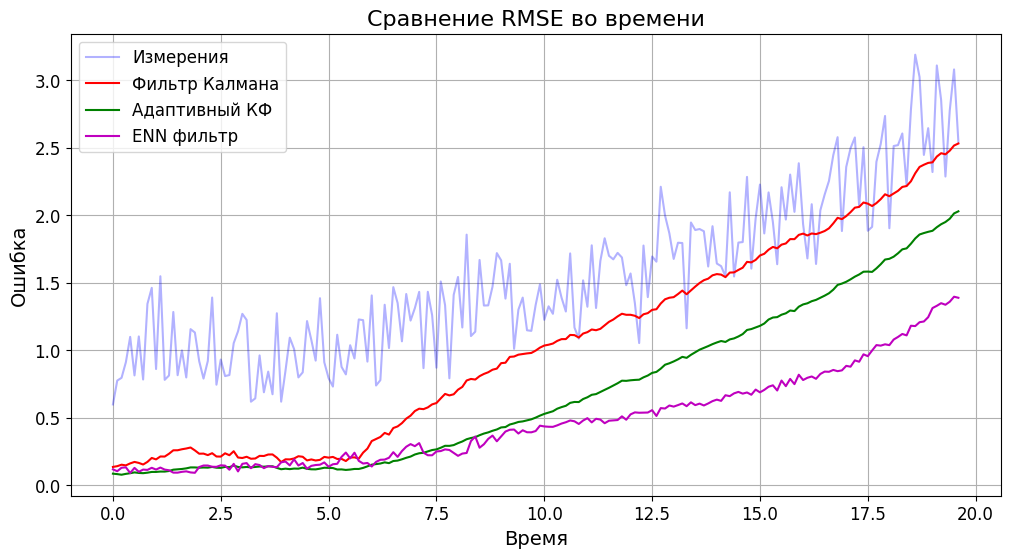

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Гиперпараметры
lr_cur = 0.001
hidden_size = 32 # Размер скрытого состояния
num_layers = 1    # Количество RNN-слоев
# +Алгоритм обучения

epochs = 1000
patience = 300
input_size = 4    # Каждый входной вектор 3D

# Инициализация модели
model = SequenceRNN(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr_cur)
# Для ранней остановки
best_val_loss = float('inf')
best_model = None

print("Best b: ", best_b)
no_improve = 0

for epoch in range(epochs):
    # Обучение
    model.train()
    train_outputs = model(inputs)
    train_loss = criterion(train_outputs, targets)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Валидация
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)

    # Логирование
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model,
            'val_loss': best_val_loss,
            'train_loss': train_loss.item(),
        }, 'best_model.pth')
    else:
        no_improve += 1

    # Ранняя остановка
    if no_improve >= patience:
        print(f'Ранняя остановка на эпохе {epoch}, лучший Val Loss: {best_val_loss:.4f}')
        break

    if train_loss.item() < 0.002:
        print("Ошибка меньше заданного порога - окончание цикла обучения.")
        break

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
print(f'Обучение завершено. Лучший Val Loss: {best_val_loss:.4f}')


# Использование модели
model.eval()
predictions = model.predict(X_train)
print("(M, N):",)
x_enn, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions,
                        y_cec_train, Q_new, R_new)

pred_val = model.predict(X_val)
x_enn_val, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_val, y_cec_val,
                             Q_new, R_new, fl_train=False)

# Тестовая выборка:
pred_test2 = model.predict(X_test2)
y_enn_test, rmse_row1, rmse_row2 = result_enn_rmse(x_true2, x_noise2, y_measure2, x_sage_husa2,
                                  pred_test2, y_c_ec2, Q_new, R_new, fl_train=False, Ge=Ge)
x_st = x_start + 1
meas_rmse_time = rmse_in_time(x_true2[:, x_st:, 1], y_measure2[:, x_st:,0])
kalman_rmse_time = rmse_in_time(x_true2[:, x_st:, 1], x_kalman2[:, x_st:,1])
akf_rmse_time = rmse_in_time(x_true2[:, x_st:, 1], x_sage_husa2[:, x_st:,1])
enn_rmse_time = rmse_in_time(x_true2[:, x_st:, 1], y_enn_test)

# График
time = np.arange(N-x_st) * dt
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, kalman_rmse_time, 'r', label='Фильтр Калмана')
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.plot(time, enn_rmse_time, 'm', label='ENN фильтр')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

s = s_qr + '_rmse_U=4.jpg'
plt.savefig(s, dpi=150, bbox_inches='tight')  # JPEG формат

plt.show()
files.download(s)

### Добавляем в df

In [ ]:
#!!!!!!!
df_true = df_true.iloc[:-1]  # удаляем последнюю строку
df_measure = df_measure.iloc[:-1]  # удаляем последнюю строку

In [ ]:
# Для df_true
new_row = [s_qr] + rmse_row1 + [train_loss.item(), best_val_loss.item(), best_b, all_seq_s, N, armse_orig, armse_filt]
df_true.loc[len(df_true)] = new_row

# Для df_measure
new_row = [s_qr] + rmse_row2
df_measure.loc[len(df_measure)] = new_row
display(df_true)
display(df_measure)

,"Q, R",Измеренный y,Kalman,Sage-Husa,ENN,train_loss,val_loss,b,M,N,ARMSE_orig,ARMSE_filt
0,"Q, R",1.640103,0.910115,1.257637,0.967175,1.003532,0.234196,0.98,15,200,3.415439,3.594285
1,"Qx100, R100",1.640103,1.316322,1.360710,1.225961,0.709354,0.454948,0.70,15,200,3.415439,3.858854
2,"Qx100, Rx100",1.640103,0.910023,1.284835,1.116818,0.616883,0.358894,0.98,15,200,3.415439,3.467106
3,"Q100, R100",1.640103,0.918282,0.906623,0.588645,0.528456,0.120687,0.94,15,200,3.415439,4.441907


,"Q, R",y&Kalman,y&Sage-Husa,y&ENN
0,"Q, R",1.628972,0.961705,1.126318
1,"Qx100, R100",1.870947,0.774785,0.947152
2,"Qx100, Rx100",1.628895,0.950849,1.146665
3,"Q100, R100",1.632524,1.085252,1.415857


### Сохранение

In [ ]:
# Импорт

# Сохраняем в файл (на виртуальной машине Colab)
df_true.to_excel("сравнение с true_U=4.xlsx", index=False, engine='openpyxl')
# Скачиваем файл на компьютер
files.download("сравнение с true_U=4.xlsx")

df_measure.to_excel("сравнение с measure_y_U=4.xlsx", index=False, engine='openpyxl')
files.download("сравнение с measure_y_U=4.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Перебор гиперпараметров ENN

In [ ]:
#from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from itertools import product
from copy import deepcopy
import torch.optim as optim
import itertools

In [ ]:
class SequenceRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(SequenceRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                         batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)  # Каждый шаг → 1 число

    def forward(self, x):
        # x shape: (batch_size, 300, 3)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)  # out shape: (batch_size, 300, hidden_size)
        out = self.fc(out)  # shape: (batch_size, 300, 1)
        return out
    def predict(self, x):
        # Переводим модель в режим оценки
        self.eval()

        # Автоматическое преобразование входных данных
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)

        # Добавляем размерность батча если нужно
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # Вычисление предсказания без вычисления градиентов
        with torch.no_grad():
            prediction = self.forward(x)

        return prediction.squeeze().numpy()  # Возвращаем numpy array

In [ ]:
# Параметры для перебора
param_grid = {
    'hidden_size': [8, 12, 32, 64],
    'lr': [0.01, 0.001, 0.0001]
}

# Фиксированные параметры
input_size = 3  # Пример: 3 признака (x, y, z)
num_layers = 1
epochs = 1000
patience = 200  # Для ранней остановки

# Лучшие параметры и метрики
best_val_loss = float('inf')
best_params = None
best_model_state = None

# Перебор всех комбинаций параметров
for params in itertools.product(*param_grid.values()):
    current_params = dict(zip(param_grid.keys(), params))
    print(f"\nTraining with params: {current_params}")

    # Инициализация модели
    model = SequenceRNN(input_size, current_params['hidden_size'], num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=current_params['lr'])

    best_epoch_loss = float('inf')
    best_epoch_model = None
    no_improve = 0

    # Обучение
    for epoch in range(epochs):
        model.train()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Валидация
        with torch.no_grad():
            #val_outputs = model(val_inputs)
            val_outputs = model.predict(val_inputs)

            val_outputs = torch.FloatTensor(val_outputs)
            val_outputs = val_outputs.unsqueeze(-1)

            val_loss = criterion(val_outputs, val_targets)

        # Сохранение лучшей модели по валидации
        if val_loss < best_epoch_loss:
            best_epoch_loss = val_loss
            best_epoch_model = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        # Логирование
        if (epoch+1) % 500 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

        # Ранняя остановка
        #if no_improve >= patience or loss.item() < 0.001:
            #print(f"Ранняя остановка на эпохе {epoch+1}")
            #break

    # Сохранение результатов для текущей комбинации параметров
    print(f"Best val loss for {current_params}: {best_epoch_loss:.4f}")
    torch.save({
        'params': current_params,
        'model_state_dict': best_epoch_model,
        'val_loss': best_epoch_loss.item(),
        'train_loss': loss.item()
    }, f"model_h{current_params['hidden_size']}_lr{current_params['lr']}.pth")

    # Обновление глобально лучшей модели
    if best_epoch_loss < best_val_loss:
        best_val_loss = best_epoch_loss
        best_params = current_params
        best_model_state = best_epoch_model
        print("Новая лучшая модель!")

# Сохранение лучшей модели
print("\nЛучшие параметры:", best_params)
print(f"Лучшая валидационная ошибка: {best_val_loss:.4f}")

torch.save({
    'params': best_params,
    'model_state_dict': best_model_state,
    'val_loss': best_val_loss.item()
}, "best_model.pth")

# Загрузка и проверка лучшей модели
best_model = SequenceRNN(input_size, best_params['hidden_size'], num_layers)
best_model.load_state_dict(torch.load("best_model.pth")['model_state_dict'])
best_model.eval()

# Финальная оценка
with torch.no_grad():
    train_pred = best_model.predict(inputs) #best_model(inputs)
    val_pred = best_model.predict(val_inputs) #best_model(val_inputs)
    #train_rmse = np.sqrt(mean_squared_error(train_pred.numpy(), targets.numpy()))
    #val_rmse = np.sqrt(mean_squared_error(val_pred.numpy(), val_targets.numpy()))

print(f"\nФинальные результаты:")
#print(f"Train RMSE: {train_rmse:.4f}")
#print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Лучшие параметры: hidden_size={best_params['hidden_size']}, lr={best_params['lr']}")


Training with params: {'hidden_size': 8, 'lr': 0.01}
Epoch [500/1000], Train Loss: 7.1242, Val Loss: 8.5334
Epoch [1000/1000], Train Loss: 7.0648, Val Loss: 8.0856
Best val loss for {'hidden_size': 8, 'lr': 0.01}: 7.7678
Новая лучшая модель!

Training with params: {'hidden_size': 8, 'lr': 0.001}
Epoch [500/1000], Train Loss: 8.1171, Val Loss: 11.4416
Epoch [1000/1000], Train Loss: 7.5322, Val Loss: 10.6014
Best val loss for {'hidden_size': 8, 'lr': 0.001}: 10.3724

Training with params: {'hidden_size': 8, 'lr': 0.0001}
Epoch [500/1000], Train Loss: 10.0390, Val Loss: 13.3426
Epoch [1000/1000], Train Loss: 9.6578, Val Loss: 13.5847
Best val loss for {'hidden_size': 8, 'lr': 0.0001}: 12.7454

Training with params: {'hidden_size': 12, 'lr': 0.01}
Epoch [500/1000], Train Loss: 7.2515, Val Loss: 9.4500
Epoch [1000/1000], Train Loss: 7.0965, Val Loss: 8.4700
Best val loss for {'hidden_size': 12, 'lr': 0.01}: 8.1916

Training with params: {'hidden_size': 12, 'lr': 0.001}
Epoch [500/1000], Tr

In [ ]:
# Параметры для перебора
all_params = {
    'hidden_size': [12, 64, 128],
    'lr': [0.01, 0.001],
    'optimizer': ['Adam', 'NAdam', 'RMSProp']
}

# Генерация данных (замените на свои реальные данные)
input_size = 3
num_layers = 1

# Для сохранения результатов
results = []
best_val_loss = float('inf')
best_params = None
best_model = None
patience = 100  # Для ранней остановки

for params in itertools.product(*param_grid.values()):
    current_params = dict(zip(param_grid.keys(), params))
    print(f"\nTraining with params: {current_params}")

    model = SequenceRNN(input_size, current_params['hidden_size'], num_layers)
    criterion = nn.MSELoss()

    # Выбор оптимизатора
    optimizers = {
        'Adam': optim.Adam,
        'NAdam': optim.NAdam,
        'RMSProp': optim.RMSprop
    }
    optimizer = optimizers[current_params['optimizer']](model.parameters(), lr=current_params['lr'])

    # Обучение с отслеживанием валидационной ошибки
    no_improve = 0
    best_epoch_loss = float('inf')

    for epoch in range(1000):
        model.train()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Валидация
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_targets)

        # Проверка на улучшение
        if val_loss < best_epoch_loss:
            best_epoch_loss = val_loss
            no_improve = 0
            current_best_state = deepcopy(model.state_dict())
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}, лучший Val Loss: {best_epoch_loss:.4f}")
            break

    # Сохранение результатов для этой конфигурации
    results.append({
        'params': current_params,
        'val_loss': best_epoch_loss.item(),
        'train_loss': loss.item()
    })

    # Проверка на лучшую модель
    if best_epoch_loss < best_val_loss:
        best_val_loss = best_epoch_loss
        best_params = current_params
        best_model = current_best_state
        print(f"Новый лучший результат: Val Loss = {best_val_loss:.4f}")

# Вывод результатов
print("\nЛучшие параметры:", best_params)
print("Лучшая валидационная ошибка:", best_val_loss.item())

# Сохранение лучшей модели
torch.save({
    'model_state_dict': best_model,
    'best_params': best_params,
    'val_loss': best_val_loss
}, 'best_model_val.pth')


Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 136, лучший Val Loss: 0.0469
Новый лучший результат: Val Loss = 0.0469

Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'NAdam'}
Ранняя остановка на эпохе 122, лучший Val Loss: 0.0468
Новый лучший результат: Val Loss = 0.0468

Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'RMSProp'}
Ранняя остановка на эпохе 104, лучший Val Loss: 0.0476

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 179, лучший Val Loss: 0.0492

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'NAdam'}
Ранняя остановка на эпохе 325, лучший Val Loss: 0.0485

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'RMSProp'}
Ранняя остановка на эпохе 105, лучший Val Loss: 0.0472

Training with params: {'hidden_size': 64, 'lr': 0.01, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 113, лучший Val L

In [ ]:

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
print(f'Обучение завершено. Лучший Val Loss: {best_val_loss:.4f}')


# Использование модели
model.eval()
predictions = model.predict(X_train)
print("(M, N):",)
x_enn = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions, y_cec_train)


pred_test = model.predict(X_val)
x_enn_test = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_test, y_cec_val,fl_train=False)

In [ ]:
checkpoint = torch.load('best_model_val.pth')
model = SequenceRNN(input_size, checkpoint['best_params']['hidden_size'], num_layers)
model.load_state_dict(checkpoint['model_state_dict'])

In [ ]:
X_val.shape

(6, 300, 3)

In [ ]:
# 1. Загрузка сохраненной модели
checkpoint = torch.load('best_model_val.pth')

# Параметры модели (должны соответствовать тем, что использовались при обучении)
input_size = 3  # Должно совпадать с размерностью входных данных
num_layers = 1   # Должно совпадать с обучением

# 2. Инициализация модели с параметрами из checkpoint
model = SequenceRNN(
    input_size=input_size,
    hidden_size=checkpoint['best_params']['hidden_size'],
    num_layers=num_layers
)

# 3. Загрузка весов
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Переводим модель в режим оценки

# 4. Подготовка новых данных для предсказания (пример)
# Должны иметь shape (batch_size, sequence_length, input_size)
new_data = X_train # 5 последовательностей по 300 шагов
new_data_tensor = torch.FloatTensor(new_data)

# 5. Получение предсказаний
with torch.no_grad():
    predictions = model(new_data_tensor)

predictions_2d = predictions.squeeze(-1)
print("(M, N):",)
x_enn = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions_2d, y_cec_train)

with torch.no_grad():
    predictions = model(val_inputs)
predictions_2d = predictions.squeeze(-1)
x_enn_test = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions_2d, y_cec_val,fl_train=False)

(M, N):
(24, 300)
RMSE скорости

True Vs Measure y     1.700018244708564
True Vs State X       1.3800362133254593
True Vs Filtered      1.360565232550835
True Vs ENN           1.362773542235234

State X Vs Measure y     1.00265902619618
State X Vs Filtered      0.21710337602551066
State X Vs ENN           0.21827604937879863
(6, 300)
RMSE скорости

True Vs Measure y     1.9503334876956246
True Vs State X       1.7115669054698848
True Vs Filtered      1.688588419342022
True Vs ENN           1.704941889117018

State X Vs Measure y     0.9721746752099282
State X Vs Filtered      0.21626316236238602
State X Vs ENN           0.2159218267552391


/tmp/ipython-input-4141434494.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_enn = predictions + y_cec[:,:,1]
/tmp/ipython-input-4141434494.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_enn = predictions + y_cec[:,:,1]


{'hidden_size': 64, 'lr': 0.001, 'optimizer': 'Adam'} 0.0884

{'hidden_size': 256, 'lr': 0.001, 'optimizer': 'Adam'} 0.0945

{'hidden_size': 12, 'lr': 0.001}: 0.0965

{'hidden_size': 25, 'lr': 0.001}: 0.0954
hidden_size: 5, 3-12

In [ ]:
# Использование модели - надо разобраться

# 1. Сохраняем обученную модель
torch.save(model.state_dict(), 'sequence_rnn.pth')

# 2. Загружаем модель для предсказаний
loaded_model = SequenceRNN(input_size=3, hidden_size=128, num_layers=1)
loaded_model.load_state_dict(torch.load('sequence_rnn.pth'))


# 3. Выполнение предсказания
predictions = loaded_model.predict(X_train)

print("Форма предсказаний:", predictions.shape)  # Должно быть (300,)

In [ ]:
x_enn = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions, y_cec_train)

In [ ]:
pred_test = loaded_model.predict(X_test)
x_enn_test = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_test, y_cec_test,fl_train=False)

# Тест задача 2

In [ ]:
def model_2_angular_pos(x0, P0, Q, R, F, S, Ge, N, plot_fl=False, vybrosy=False,
                       razbros_vybrosov=50.0, chastota_vybrosov=0.1):
    """
    Генерация данных для системы с шумами

    Parameters:
    x0 : array_like - начальное матожидание состояния
    P0 : array_like - начальная ковариационная матрица состояния
    Q : float - дисперсия шума процесса
    R : float - дисперсия шума измерений
    F : array_like - матрица перехода состояния
    S : array_like - вектор управления
    B : array_like - вектор шума процесса
    N : int - количество шагов
    """
    # Размерности
    n = P0.shape[0]  # размерность состояния (2)
    S = S.reshape(n)

    # Генерация шумов
    #w = np.random.normal(0, Q, (N, 1))  # шум процесса
    #v = np.random.normal(0, R, (N, 1))  # шум измерений

    w = np.random.multivariate_normal(np.array([0]), Q, N)  # шум процесса
    v = np.random.multivariate_normal(np.array([0]), R, N)  # шум измерений

    # Инициализация массивов
    states_history = np.zeros((N, n))
    x_true_arr = np.zeros((N, n))
    y = np.zeros((N,1))

    # Начальное состояние - случайное из распределения N(x0, P0)
    X_current = x0 #np.random.multivariate_normal(x0, P0) #.reshape(-1, 1)

    for j in range(N):
        x_true_val = F @ x_true_arr[j-1] + S * 6 if j > 0 else x0
        x_true_arr[j] = x_true_val

        X_current = F @ X_current + S * 6 + Ge @ w[j] #.reshape(-1, 1)
        states_history[j] = X_current

        # Измерение (первая компонента + шум измерений)
        current_measurement = X_current[0] + v[j]

        # Добавление выбросов
        if vybrosy and np.random.rand() < chastota_vybrosov:
            current_measurement += np.random.normal(0, razbros_vybrosov)

        y[j] = current_measurement

    if plot_fl:
        plot_model2_results(states_history, x_true_arr, y, N)

    return x_true_arr, states_history, y

## Один запуск (данные)

In [ ]:
N = 300
all_seq_s = 30
all_seq_s2 = 10
dim_X = 2  #размерность X
num_Xi = 0 #индекс целевой компоненты вектора состояния

In [ ]:
F = np.array([[1, 0.080156],
              [0, 0.631283]])
S = np.array([[0.003395], [0.063083]])
H = np.array([[1, 0]])
Ge = np.array([[0], [1]])

x0 = np.array([0., 0.])
P0 = np.diag([0.01, 0.01])
Q = np.array([[0.01]])
R = np.array([[0.1]])
T=0.1

In [ ]:
x_true = np.zeros((all_seq_s, N, dim_X))
x_noise = np.zeros((all_seq_s, N, dim_X))
y_measure1 = np.zeros((all_seq_s, N, 1))
for i in range(all_seq_s):
  clear_x, unfil_x, zs = model_2_angular_pos(x0, P0, Q, R, F, S, Ge, N)
  x_true[i, :, :] = clear_x
  x_noise[i, :, :] = unfil_x
  y_measure1[i, :, :] = zs

In [ ]:
# Данные тест
x_true2 = np.zeros((all_seq_s2, N, dim_X))
x_noise2 = np.zeros((all_seq_s2, N, dim_X))
y_measure2 = np.zeros((all_seq_s2, N, 1))
for i in range(all_seq_s2):
  clear_x, unfil_x, zs = model_2_angular_pos(x0, P0, Q, R, F, S, Ge, N)
  x_true2[i, :, :] = clear_x
  x_noise2[i, :, :] = unfil_x
  y_measure2[i, :, :] = zs

#таблицы для сохранения
columns = ['Q, R', 'Измеренный y', 'Kalman', 'Sage-Husa', 'ENN', 'train_loss', 'val_loss', 'b']
df_true = pd.DataFrame(columns=columns)

columns = ['Q, R', 'y&Kalman', 'y&Sage-Husa', 'y&ENN']
df_measure = pd.DataFrame(columns=columns)

## Меняем

### Параметр b

In [ ]:
Q_new=Q
R_new=R
s_qr = 'Q, R'
best_b=0.07

In [ ]:
best_b=0.01

b_values = np.arange(0.01, 1., 0.01)[:-1]
#b_values = np.arange(0.5, 1., 0.001)[:-1]

Q/100, R/100
Q*100, R*100
Q/100, R*100
Q*100, R/100


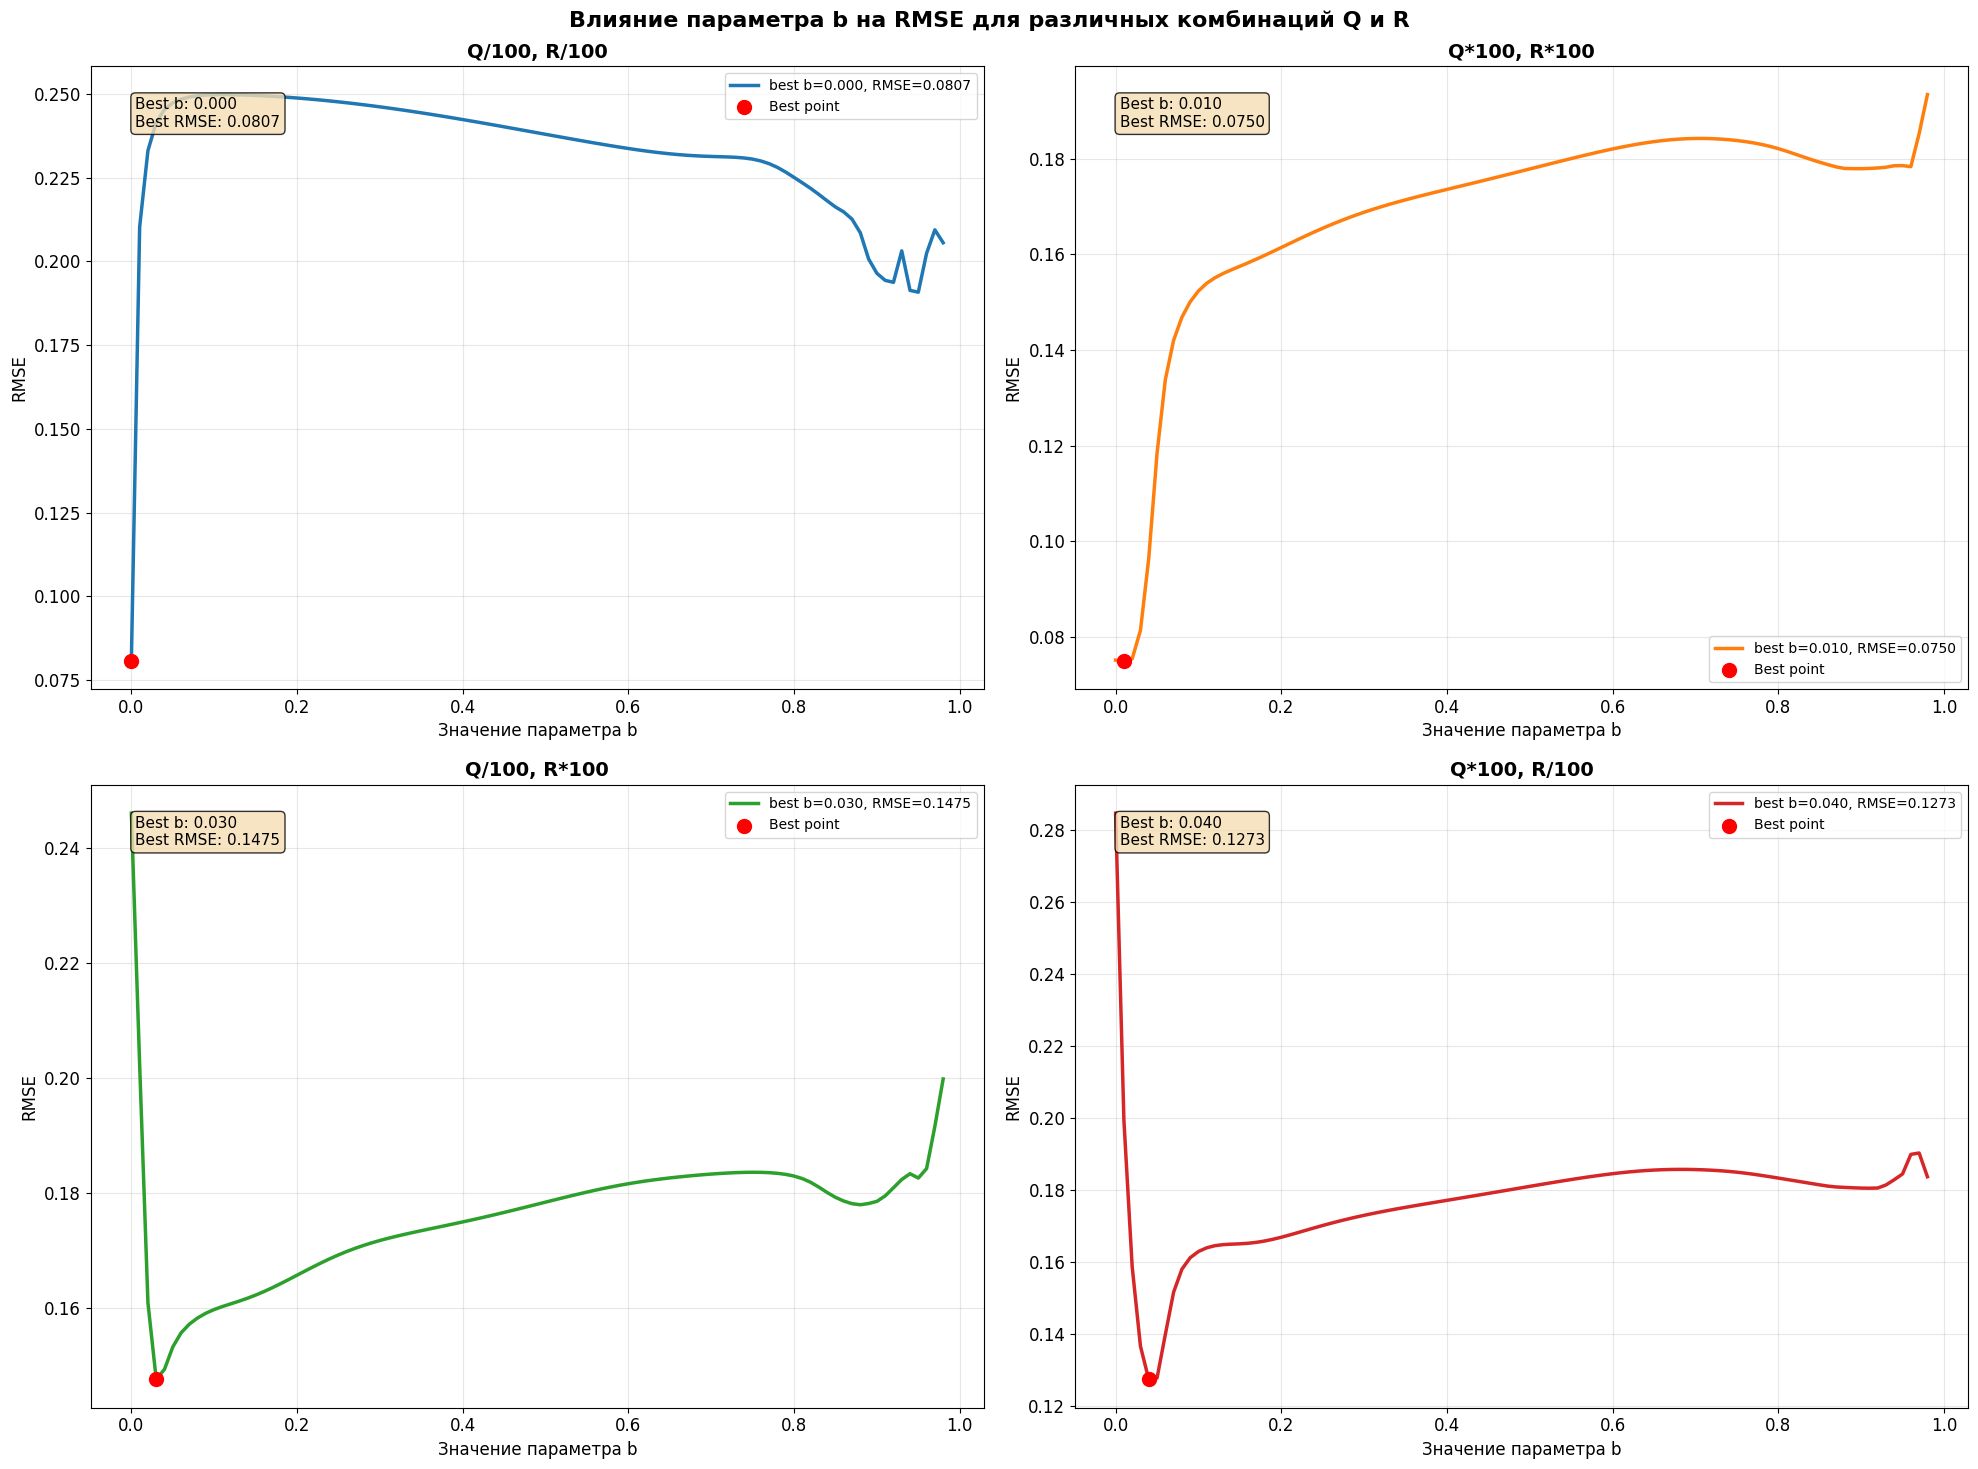


Лучшие результаты для каждой комбинации параметров:
Q/100, R/100: b = 0.000, ARMSE = 0.0807
Q*100, R*100: b = 0.010, ARMSE = 0.0750
Q/100, R*100: b = 0.030, ARMSE = 0.1475
Q*100, R/100: b = 0.040, ARMSE = 0.1273


In [ ]:
# Комбинации параметров (Q0, R0)
param_combinations = [
    ('Q/100, R/100', Q/100, R/100),
    ('Q*100, R*100', Q*100, R*100),
    ('Q/100, R*100', Q/100, R*100),
    ('Q*100, R/100', Q*100, R/100)
]

# Создаем фигуру с 4 субплoтами (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()  # Преобразуем в одномерный массив для удобства

# Словарь для хранения лучших результатов
best_results = {}
count = all_seq_s // 3

# Перебираем все комбинации параметров
for idx, (label, Q0, R0) in enumerate(param_combinations):
    errors = []
    print(label)

    # Перебираем все значения b
    for b in b_values:
        x_sage_husa = np.zeros((count, N, dim_X))

        for i in range(count):
            xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q0, R0, Ge, alpha=b, Ksi_U=S*6)
            x_sage_husa[i] = xf

        # Вычисляем ошибку RMSE для компоненты num_Xi
        err1 = calculate_ARMSE_n_dim(x_noise[:count, :, num_Xi], x_sage_husa[:, :, num_Xi])
        errors.append(err1)

    # Находим лучшее значение b для этой комбинации
    best_idx = np.argmin(errors)
    best_b = b_values[best_idx]
    best_error = errors[best_idx]
    best_results[label] = (best_b, best_error)

    # Строим график на соответствующем субплoте
    ax = axes[idx]
    ax.plot(b_values, errors, linewidth=2.5, color=f'C{idx}',
            label=f'best b={best_b:.3f}, RMSE={best_error:.4f}')

    # Отмечаем лучшую точку на графике
    ax.scatter(best_b, best_error, color='red', s=100, zorder=5,
               label=f'Best point')

    # Настройка каждого графика
    ax.set_title(f'{label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Значение параметра b', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    # Добавляем текстовую информацию о лучших параметрах
    ax.text(0.05, 0.95, f'Best b: {best_b:.3f}\nBest RMSE: {best_error:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Общий заголовок для всех графиков
fig.suptitle("Влияние параметра b на RMSE для различных комбинаций Q и R",
             fontsize=16, fontweight='bold', y=0.98)

# Улучшаем расположение графиков
plt.tight_layout()

# Сохраняем все графики в один файл
#plt.savefig(s_qr+'_multiple_b_plots.jpg', dpi=150, bbox_inches='tight')
plt.show()

# Вывод лучших результатов
print("\n" + "="*60)
print("Лучшие результаты для каждой комбинации параметров:")
print("="*60)
for label, (b, error) in best_results.items():
    print(f"{label}: b = {b:.3f}, ARMSE = {error:.4f}")

### Катя

In [ ]:
N = 200
all_seq_s = 20
dim_X = 2  # размерность X

# Массивы для сохранения сгенерированных данных
x_true_all = np.zeros((all_seq_s, N, dim_X))  # истинные состояния
x_noise_all = np.zeros((all_seq_s, N, dim_X)) # состояния с шумом процесса
y_measure_all = np.zeros((all_seq_s, N, 1))   # измерения
filter_states_Katia = np.zeros((all_seq_s, N, 1))

# Параметры системы
T = 0.1
theta1 = 4.6
theta2 = 0.787
u = 6.0
R_true = 0.1
Q_true = 0.01
n_steps = 200

# Матрицы системы из уравнений (4.1)
F = np.array([[1, 0.080156],
              [0, 0.631283]])

B = np.array([[0.003395],
              [0.063083]])

H = np.array([[1, 0]])
Gamma = np.array([[0], [1]])

# Функция для выполнения одного запуска фильтра
def run_adaptive_filter_simple(Q0, R0, b, seed=None, save_data=False, run_idx=0):
    if seed is not None:
        np.random.seed(seed)

    # Генерация данных
    true_states = []
    measurements = []
    process_noise_states = []  # состояния с шумом процесса

    x_current = np.array([0, 0]).reshape(-1, 1)
    x_current_noise = np.array([0, 0]).reshape(-1, 1)  # для состояний с шумом

    for k in range(n_steps):
        Q_cov = np.array([[Q_true]])
        # Генерация шума процесса
        w = np.random.multivariate_normal(np.zeros(1), Q_cov, (1,1))

        # Обновление истинного состояния
        x_current = F @ x_current + B * u + Gamma * w
        true_states.append(x_current.copy().flatten())

        # Сохраняем состояние с шумом процесса
        process_noise_states.append(x_current.copy().flatten())

        R_cov = np.array([[R_true]])
        # Генерация шума измерений
        v = np.random.multivariate_normal(np.zeros(1), R_cov, (1,1))

        # Генерация измерения
        z = H @ x_current + v
        measurements.append(z[0, 0])

    true_states = np.array(true_states)
    process_noise_states = np.array(process_noise_states)
    measurements = np.array(measurements)

    # Сохранение сгенерированных данных в глобальные массивы
    if save_data and run_idx < all_seq_s:
        x_true_all[run_idx] = true_states
        x_noise_all[run_idx] = process_noise_states
        y_measure_all[run_idx] = measurements.reshape(-1, 1)

    # Инициализация фильтра
    x_est = np.array([0, 0]).reshape(-1, 1)
    P_est = np.array([[0.01, 0], [0, 0.01]])
    Q_est = np.array([[Q0]])
    R_est = np.array([[R0]])

    updated_measurements = []

    # Адаптивная фильтрация
    for k in range(n_steps):
        # I. ЭТАП ПРОГНОЗ
        x_pred = F @ x_est + B * u
        P_pred = F @ P_est @ F.T + Gamma @ Q_est @ Gamma.T

        # II. ФИЛЬТРАЦИЯ
        y_k1 = measurements[k]
        epsilon = y_k1 - H @ x_pred
        B_cov = H @ P_pred @ H.T + R_est
        K = P_pred @ H.T @ np.linalg.inv(B_cov)
        x_est = x_pred + K @ epsilon
        P_est = (np.eye(2) - K @ H) @ P_pred

        y_k1_k1 = H @ x_est
        updated_measurements.append(y_k1_k1[0, 0])

        # III. БЛОК АДАПТАЦИИ
        if b < 1.0:
            Gamma_T_Gamma = Gamma.T @ Gamma  # Γ_{k+1}^T Γ_{k+1}
            inv_Gamma_T_Gamma = np.linalg.inv(Gamma_T_Gamma)  # (Γ_{k+1}^T Γ_{k+1})^{-1}
            G = inv_Gamma_T_Gamma @ Gamma.T  # G_{k+1} = (Γ_{k+1}^T Γ_{k+1})^{-1} Γ_{k+1}^T
            innovation_Q = G @ K @ epsilon @ epsilon.T @ K.T @ G.T
            Q_est = b * Q_est + (1 - b) * innovation_Q

            # Адаптация R
            epsilon_post = y_k1 - H @ x_est
            innovation_R = epsilon_post @ epsilon_post.T
            H_P_H = H @ P_pred @ H.T
            R_est = b * R_est + (1 - b) * (innovation_R + H_P_H)

    updated_measurements = np.array(updated_measurements)
    filter_states_Katia = updated_measurements

    # Квадраты ошибок для первой компоненты (положения)
    squared_errors = (true_states[:, 0] - updated_measurements) ** 2

    return squared_errors

# Функция для расчета ARMSE
def calculate_armse(n_runs, Q0, R0, b, save_data=False):
    all_squared_errors = []

    for run in range(n_runs):
        squared_errors = run_adaptive_filter_simple(Q0, R0, b, seed=run,
                                                   save_data=save_data, run_idx=run)
        all_squared_errors.append(squared_errors)

    all_squared_errors = np.array(all_squared_errors)

    # ARMSE по формуле: sqrt(1/(M*N) * sum(sum(squared_errors)))
    total_sum = np.sum(all_squared_errors)
    armse = np.sqrt(total_sum / (n_runs * n_steps))

    return armse

# 4 случая
cases = [
    {
        'name': 'Q_ucm/100, R_ucm/100',
        'Q0': Q_true / 100,
        'R0': R_true / 100
    },
    {
        'name': 'Q_ucm*100, R_ucm*100',
        'Q0': Q_true * 100,
        'R0': R_true * 100
    },
    {
        'name': 'Q_ucm/100, R_ucm*100',
        'Q0': Q_true / 100,
        'R0': R_true * 100
    },
    {
        'name': 'Q_ucm*100, R_ucm/100',
        'Q0': Q_true * 100,
        'R0': R_true / 100
    }
]

# поиск оптимального b
n_runs = 30  # количество запусков
b_values = np.arange(0.01, 1.0, 0.01)  # значения b от 0.01 до 0.99 с шагом 0.01

# Поиск оптимального b для каждого случая
results = []

plt.figure(figsize=(15, 10))

for i, case in enumerate(cases):
    print(f"Случай: {case['name']}")
    print(f"  Q0 = {case['Q0']:.6f}, R0 = {case['R0']:.6f}")

    armse_results = []
    min_armse = float('inf')
    optimal_b = 0

    # Перебираем значения b
    for b in b_values:
        # Сохраняем данные только для первого случая (чтобы не дублировать)
        save_data = (i == 0)  # сохраняем данные только для первого случая
        armse = calculate_armse(n_runs, case['Q0'], case['R0'], b, save_data=save_data)
        armse_results.append(armse)

        if armse < min_armse:
            min_armse = armse
            optimal_b = b

    results.append({
        'case': case['name'],
        'Q0': case['Q0'],
        'R0': case['R0'],
        'optimal_b': optimal_b,
        'min_armse': min_armse,
        'b_values': b_values.copy(),
        'armse_values': armse_results.copy()
    })

    print(f"  Оптимальное b: {optimal_b:.2f}, минимальная ARMSE: {min_armse:.6f}")
    print()

    # Строим график для этого случая
    plt.subplot(2, 2, i+1)
    plt.plot(b_values, armse_results, 'b-', linewidth=2)
    plt.axvline(x=optimal_b, color='r', linestyle='--', alpha=0.7,
                label=f'Оптимальное b = {optimal_b:.2f}')
    plt.xlabel('Параметр b')
    plt.ylabel('ARMSE')
    plt.title(f'{case["name"]}\nОптимальное b = {optimal_b:.2f}, ARMSE = {min_armse:.5f}')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# Вывод информации о сохраненных данных
print("\n" + "="*80)
print("ИНФОРМАЦИЯ О СОХРАНЕННЫХ ДАННЫХ")
print("="*80)
print(f"x_true_all shape: {x_true_all.shape}")
print(f"x_noise_all shape: {x_noise_all.shape}")
print(f"y_measure_all shape: {y_measure_all.shape}")
print(f"Пример первых 5 значений первого запуска:")
print(f"x_true[0, :5, 0]: {x_true_all[0, :5, 0]}")
print(f"y_measure[0, :5, 0]: {y_measure_all[0, :5, 0]}")

# таблица
print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(f"{'Начальные приближения':<25} {'Q0':<12} {'R0':<12} {'b_opt':<8} {'ARMSE':<10}")
print("-" * 80)
for result in results:
    print(f"{result['case']:<25} {result['Q0']:<12.6f} {result['R0']:<12.6f} {result['optimal_b']:<8.2f} {result['min_armse']:<10.6f}")

Случай: Q_ucm/100, R_ucm/100
  Q0 = 0.000100, R0 = 0.001000


KeyboardInterrupt: 

<Figure size 1500x1000 with 0 Axes>

In [ ]:
N = 200
all_seq_s = 20
dim_X = 2  # размерность X

# Массивы для сохранения сгенерированных данных
x_true_all = np.zeros((all_seq_s, N, dim_X))  # истинные состояния
x_noise_all = np.zeros((all_seq_s, N, dim_X)) # состояния с шумом процесса
y_measure_all = np.zeros((all_seq_s, N, 1))   # измерения
filter_states_Katia = np.zeros((all_seq_s, N, 1))

# Параметры системы
T = 0.1
theta1 = 4.6
theta2 = 0.787
u = 6.0
R_true = 0.1
Q_true = 0.01
n_steps = 200

# Матрицы системы из уравнений (4.1)
F = np.array([[1, 0.080156],
              [0, 0.631283]])

B = np.array([[0.003395],
              [0.063083]])

H = np.array([[1, 0]])
Gamma = np.array([[0], [1]])

# Функция для выполнения одного запуска фильтра
def run_adaptive_filter_simple(Q0, R0, b, seed=None, save_data=False, run_idx=0):
    if seed is not None:
        np.random.seed(seed)

    # Генерация данных
    true_states = []
    measurements = []
    process_noise_states = []  # состояния с шумом процесса

    x_current = np.array([0, 0]).reshape(-1, 1)
    x_current_noise = np.array([0, 0]).reshape(-1, 1)  # для состояний с шумом

    for k in range(n_steps):
        Q_cov = np.array([[Q_true]])
        # Генерация шума процесса
        w = np.random.multivariate_normal(np.zeros(1), Q_cov, (1,1))

        # Обновление истинного состояния
        x_current = F @ x_current + B * u + Gamma * w
        true_states.append(x_current.copy().flatten())

        # Сохраняем состояние с шумом процесса
        process_noise_states.append(x_current.copy().flatten())

        R_cov = np.array([[R_true]])
        # Генерация шума измерений
        v = np.random.multivariate_normal(np.zeros(1), R_cov, (1,1))

        # Генерация измерения
        z = H @ x_current + v
        measurements.append(z[0, 0])

    true_states = np.array(true_states)
    process_noise_states = np.array(process_noise_states)
    measurements = np.array(measurements)

    # Сохранение сгенерированных данных в глобальные массивы
    if save_data and run_idx < all_seq_s:
        x_true_all[run_idx] = true_states
        x_noise_all[run_idx] = process_noise_states
        y_measure_all[run_idx] = measurements.reshape(-1, 1)

    # Инициализация фильтра
    x_est = np.array([0, 0]).reshape(-1, 1)
    P_est = np.array([[0.01, 0], [0, 0.01]])
    Q_est = np.array([[Q0]])
    R_est = np.array([[R0]])

    updated_measurements = []

    # Адаптивная фильтрация
    for k in range(n_steps):
        # I. ЭТАП ПРОГНОЗ
        x_pred = F @ x_est + B * u
        P_pred = F @ P_est @ F.T + Gamma @ Q_est @ Gamma.T

        # II. ФИЛЬТРАЦИЯ
        y_k1 = measurements[k]
        epsilon = y_k1 - H @ x_pred
        B_cov = H @ P_pred @ H.T + R_est
        K = P_pred @ H.T @ np.linalg.inv(B_cov)
        x_est = x_pred + K @ epsilon
        P_est = (np.eye(2) - K @ H) @ P_pred

        y_k1_k1 = H @ x_est
        updated_measurements.append(y_k1_k1[0, 0])

        # III. БЛОК АДАПТАЦИИ
        if b < 1.0:
            Gamma_T_Gamma = Gamma.T @ Gamma  # Γ_{k+1}^T Γ_{k+1}
            inv_Gamma_T_Gamma = np.linalg.inv(Gamma_T_Gamma)  # (Γ_{k+1}^T Γ_{k+1})^{-1}
            G = inv_Gamma_T_Gamma @ Gamma.T  # G_{k+1} = (Γ_{k+1}^T Γ_{k+1})^{-1} Γ_{k+1}^T
            innovation_Q = G @ K @ epsilon @ epsilon.T @ K.T @ G.T
            Q_est = b * Q_est + (1 - b) * innovation_Q

            # Адаптация R
            epsilon_post = y_k1 - H @ x_est
            innovation_R = epsilon_post @ epsilon_post.T
            H_P_H = H @ P_pred @ H.T
            R_est = b * R_est + (1 - b) * (innovation_R + H_P_H)

    updated_measurements = np.array(updated_measurements)
    filter_states_Katia = updated_measurements

    # Квадраты ошибок для первой компоненты (положения)
    squared_errors = (true_states[:, 0] - updated_measurements) ** 2

    return squared_errors

# Функция для расчета ARMSE
def calculate_armse(n_runs, Q0, R0, b, save_data=False):
    all_squared_errors = []

    for run in range(n_runs):
        squared_errors = run_adaptive_filter_simple(Q0, R0, b, seed=run,
                                                   save_data=save_data, run_idx=run)
        all_squared_errors.append(squared_errors)

    all_squared_errors = np.array(all_squared_errors)

    # ARMSE по формуле: sqrt(1/(M*N) * sum(sum(squared_errors)))
    total_sum = np.sum(all_squared_errors)
    armse = np.sqrt(total_sum / (n_runs * n_steps))

    return armse

# 4 случая
cases = [
    {
        'name': 'Q_ucm/100, R_ucm/100',
        'Q0': Q_true / 100,
        'R0': R_true / 100,
        'b': 0.01
    },
    {
        'name': 'Q_ucm*100, R_ucm*100',
        'Q0': Q_true * 100,
        'R0': R_true * 100,
        'b': 0.99
    },
    {
        'name': 'Q_ucm/100, R_ucm*100',
        'Q0': Q_true / 100,
        'R0': R_true * 100,
        'b': 0.93
    },
    {
        'name': 'Q_ucm*100, R_ucm/100',
        'Q0': Q_true * 100,
        'R0': R_true / 100,
        'b': 0.9
    }
]

# поиск оптимального b
n_runs = all_seq_s  # количество запусков
b_values = np.arange(0.01, 1.0, 0.01)  # значения b от 0.01 до 0.99 с шагом 0.01

# Поиск оптимального b для каждого случая
results = []


for i, case in enumerate(cases):
    print(f"Случай: {case['name']}")
    print(f"  Q0 = {case['Q0']:.6f}, R0 = {case['R0']:.6f}")

    armse_results = []
    min_armse = float('inf')
    optimal_b = case['b']

    save_data = 1  # сохраняем данные только для первого случая
    armse = calculate_armse(n_runs, case['Q0'], case['R0'], optimal_b, save_data=save_data)
    min_armse = armse


    results.append({
        'case': case['name'],
        'Q0': case['Q0'],
        'R0': case['R0'],
        'optimal_b': optimal_b,
        'min_armse': min_armse,
        'b_values': b_values.copy()
    })

    print(f"  Оптимальное b: {optimal_b:.2f}, минимальная ARMSE: {min_armse:.6f}")
    print()

# Вывод информации о сохраненных данных
print("\n" + "="*80)
print("ИНФОРМАЦИЯ О СОХРАНЕННЫХ ДАННЫХ")
print("="*80)
print(f"x_true_all shape: {x_true_all.shape}")
print(f"x_noise_all shape: {x_noise_all.shape}")
print(f"y_measure_all shape: {y_measure_all.shape}")
print(f"Пример первых 5 значений первого запуска:")
print(f"x_true[0, :5, 0]: {x_true_all[0, :5, 0]}")
print(f"y_measure[0, :5, 0]: {y_measure_all[0, :5, 0]}")

# таблица
print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(f"{'Начальные приближения':<25} {'Q0':<12} {'R0':<12} {'b_opt':<8} {'ARMSE':<10}")
print("-" * 80)
for result in results:
    print(f"{result['case']:<25} {result['Q0']:<12.6f} {result['R0']:<12.6f} {result['optimal_b']:<8.2f} {result['min_armse']:<10.6f}")

Случай: Q_ucm/100, R_ucm/100
  Q0 = 0.000100, R0 = 0.001000
  Оптимальное b: 0.01, минимальная ARMSE: 0.178962

Случай: Q_ucm*100, R_ucm*100
  Q0 = 1.000000, R0 = 10.000000
  Оптимальное b: 0.99, минимальная ARMSE: 0.070476

Случай: Q_ucm/100, R_ucm*100
  Q0 = 0.000100, R0 = 10.000000
  Оптимальное b: 0.93, минимальная ARMSE: 0.118039

Случай: Q_ucm*100, R_ucm/100
  Q0 = 1.000000, R0 = 0.001000
  Оптимальное b: 0.90, минимальная ARMSE: 0.124750


ИНФОРМАЦИЯ О СОХРАНЕННЫХ ДАННЫХ
x_true_all shape: (20, 200, 2)
x_noise_all shape: (20, 200, 2)
y_measure_all shape: (20, 200, 1)
Пример первых 5 значений первого запуска:
x_true[0, :5, 0]: [0.02037    0.08521882 0.17185161 0.27936066 0.39269448]
y_measure[0, :5, 0]: [ 0.14691082  0.79385147 -0.13719079  0.23149731  0.52253712]

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Начальные приближения     Q0           R0           b_opt    ARMSE     
--------------------------------------------------------------------------------
Q_ucm/100, R_ucm/100      0.000100   

In [ ]:
R_new

array([[0.001]])

In [ ]:
Q_new = Q * 100
R_new = R / 100
best_b = 0.90

In [ ]:

# 2. Фильтр AKF

x_sage_husa = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  # xf = Sage_Husa_filter(y_measure1[i], x0, P0, F, H, Q0, R0, B, b=best_b)
  xf = Ahlagi_Zhou_Huang_filter(y_measure_all[i], x0, P0, F, H, Q_new, R_new, Ge, alpha=best_b, Ksi_U = S*6)
  x_sage_husa[i] = xf

x_kalman = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  xf = Kalman_filter(y_measure_all[i], x0, P0, F, H, Q_new, R_new, Ksi_U=S*6, Ge=Ge)
  x_kalman[i] = xf

#print("Фильтр Калмана: ")
#print_result_filt_rmse(x_true, x_noise, y_measure1, x_kalman, num_Xi)
#print("\nФильтр AKF: ")
#print_result_filt_rmse(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)

print("\nARMSE Фильтр Калмана: ")
print_result_filt_ARMSE(x_true_all, x_noise_all, y_measure_all, x_kalman, num_Xi)
print("\nARMSE Фильтр AKF: ")
print_result_filt_ARMSE(x_true_all, x_noise_all, y_measure_all, x_sage_husa, num_Xi)


ARMSE Фильтр Калмана: 
True x & Filt x:                0.2831
State x & Filt x:               0.2831

ARMSE Фильтр AKF: 
True x & Filt x:                0.1248
State x & Filt x:               0.1248


(np.float64(0.12475012272740939), np.float64(0.12475012272740939))

### Фильтр

In [ ]:
Q_new=Q/100
R_new=R*100
best_b=0.51

In [ ]:
# 2. Фильтр AKF

x_sage_husa = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  # xf = Sage_Husa_filter(y_measure1[i], x0, P0, F, H, Q0, R0, B, b=best_b)
  xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge, alpha=best_b, Ksi_U = S*6)
  x_sage_husa[i] = xf

x_kalman = np.zeros((all_seq_s, N, dim_X))
for i in range(all_seq_s):
  xf = Kalman_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ksi_U=S*6, Ge=Ge)
  x_kalman[i] = xf

#print("Фильтр Калмана: ")
#print_result_filt_rmse(x_true, x_noise, y_measure1, x_kalman, num_Xi)
#print("\nФильтр AKF: ")
#print_result_filt_rmse(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)

print("\nARMSE Фильтр Калмана: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_kalman, num_Xi)
print("\nARMSE Фильтр AKF: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_sage_husa, num_Xi)


# Формируем выборки
y_mc = y_measure1[:, 1:-1, 0]
y_ec1 = x_sage_husa[:, 1:-1, num_Xi]
y_ec2 = x_sage_husa[:, :-2, num_Xi]
y_ec = x_sage_husa[:, 2:, num_Xi]
y_c = x_true[:, 2:, num_Xi]
merge_model = np.stack([y_mc, y_ec1, y_ec2], axis=2)
y_c_ec = np.stack([y_c, y_ec], axis=2)


X_train, X_val, y_cec_train, y_cec_val = train_test_split(
    merge_model, y_c_ec, test_size=0.2, random_state=42, shuffle=False
)

e_train = y_cec_train[:,:,0]-y_cec_train[:,:,1]
e_val = y_cec_val[:,:,0]-y_cec_val[:,:,1]
e_train = e_train[:, :, np.newaxis]  # Форма (n, m, 1)
e_val = e_val[:, :, np.newaxis]    # Форма (k, p, 1)
print( e_train.shape, e_val.shape)


inputs = torch.FloatTensor(X_train) # batch_size, seq_len=300, input_size=3
targets = torch.FloatTensor(e_train) # Соответствующие выходы batch*300×1

val_inputs = torch.FloatTensor(X_val) # batch_size=32, seq_len=300, input_size=3
val_targets = torch.FloatTensor(e_val) # Соответствующие выходы batch*300×1


ARMSE Фильтр Калмана: 
True x & Filt x:                0.1027
Milutin Noise & Filt:           0.3609
State x & Filt x:               0.1759

ARMSE Фильтр AKF: 
True x & Filt x:                0.1552
Milutin Noise & Filt:           0.3354
State x & Filt x:               0.1286
(40, 198, 1) (10, 198, 1)


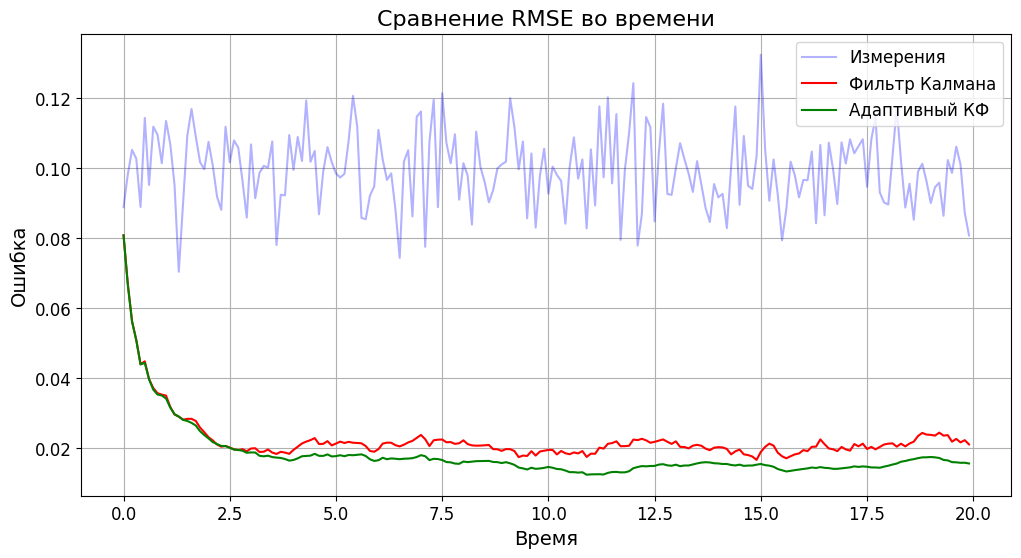

In [ ]:
meas_rmse_time = rmse_in_time(x_noise[:, :, num_Xi], y_measure1[:, :,0])
#meas_rmse_time = rmse_in_time(x_true[:, :, num_Xi], x_noise[:, :, num_Xi])
kalman_rmse_time = rmse_in_time(x_noise[:, :, num_Xi], x_kalman[:, :, num_Xi])
akf_rmse_time = rmse_in_time(x_noise[:, :, num_Xi], x_sage_husa[:, :, num_Xi])

# График
time = np.arange(N) * 0.1
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, kalman_rmse_time, 'r', label='Фильтр Калмана')
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

In [ ]:
num_X = 1
#meas_rmse_time = rmse_in_time(x_true[:, :, num_Xi], y_measure1[:, :,0])
meas_rmse_time = rmse_in_time(x_true[:, 10:, num_X], x_noise[:, 10:, num_X])
kalman_rmse_time = rmse_in_time(x_true[:, 10:, num_X], x_kalman[:, 10:, num_X])
akf_rmse_time = rmse_in_time(x_true[:, 10:, num_X], x_sage_husa[:, 10:, num_X])

# График
time = np.arange(N-10) * 0.1
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, kalman_rmse_time, 'r', label='Фильтр Калмана')
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

### Сеть

In [ ]:
# 3. Обучение ENN

input_size = 3    # Каждый входной вектор 3D
hidden_size = 12 # Размер скрытого состояния
num_layers = 1    # Количество RNN-слоев
epochs = 700
patience = 300
lr_cur = 0.001

model = SequenceRNN(input_size, hidden_size, num_layers)
# Инициализация модели
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr_cur)
# Для ранней остановки
best_val_loss = float('inf')
no_improve = 0
best_model = None


for epoch in range(epochs):
    # Обучение
    model.train()
    train_outputs = model(inputs)
    train_loss = criterion(train_outputs, targets)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Валидация
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)

    # Логирование
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model,
            'val_loss': best_val_loss,
            'train_loss': train_loss.item(),
        }, 'best_model.pth')
    else:
        no_improve += 1

    # Ранняя остановка
    if no_improve >= patience:
        print(f'Ранняя остановка на эпохе {epoch}, лучший Val Loss: {best_val_loss:.4f}')
        break

    if train_loss.item() < 0.002:
        print("Ошибка меньше заданного порога - окончание цикла обучения.")
        break

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
print(f'Обучение завершено. Лучший Val Loss: {best_val_loss:.4f}')


# Использование модели
model.eval()
predictions = model.predict(X_train)
print("(M, N):",)
x_enn, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions,
                        y_cec_train, Q_new, R_new, num_xi=num_Xi, Ksi_U = S*6, Ge = Ge)

pred_val = model.predict(X_val)
x_enn_val, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_val, y_cec_val,
                             Q_new, R_new, num_xi=num_Xi, fl_train=False, Ksi_U = S*6, Ge = Ge)

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


Epoch [0/700], Train Loss: 0.0270, Val Loss: 0.0221
Ошибка меньше заданного порога - окончание цикла обучения.
Обучение завершено. Лучший Val Loss: 0.0016
(M, N):

 (40, 198)
True Vs Measure y     0.14340004410735557
True Vs AKF         0.10270270941228589
True Vs Kalman      0.1028926673302349
True Vs ENN           0.03919271282823259

 (10, 198)
True Vs Measure y     0.14485288257845863
True Vs AKF         0.10382143021988109
True Vs Kalman      0.103981028812745
True Vs ENN           0.03972511765882499


In [ ]:
#Дублируем вывод для сравнения
print("(M, N):",)
x_enn, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, predictions,
                        y_cec_train, Q_new, R_new, num_xi=num_Xi, Ksi_U = S*6, Ge = Ge)

pred_val = model.predict(X_val)
x_enn_val, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_sage_husa, pred_val, y_cec_val,
                             Q_new, R_new, num_xi=num_Xi, fl_train=False, Ksi_U = S*6, Ge = Ge)

(M, N):

 (12, 198)
True Vs Measure y     0.3722937962475689
True Vs AKF         0.11145358598326938
True Vs Kalman      0.17611220113604242
True Vs ENN           0.10774443334579811

 (3, 198)
True Vs Measure y     0.3826231513182464
True Vs AKF         0.17507568941916657
True Vs Kalman      0.20688267048796313
True Vs ENN           0.1745088514305566


(10, 198, 1)

 (10, 198)
True Vs Measure y     0.4348649427800031
True Vs AKF         0.10065206944995168
True Vs Kalman      0.1735908588068891
True Vs ENN           0.11695711776739191


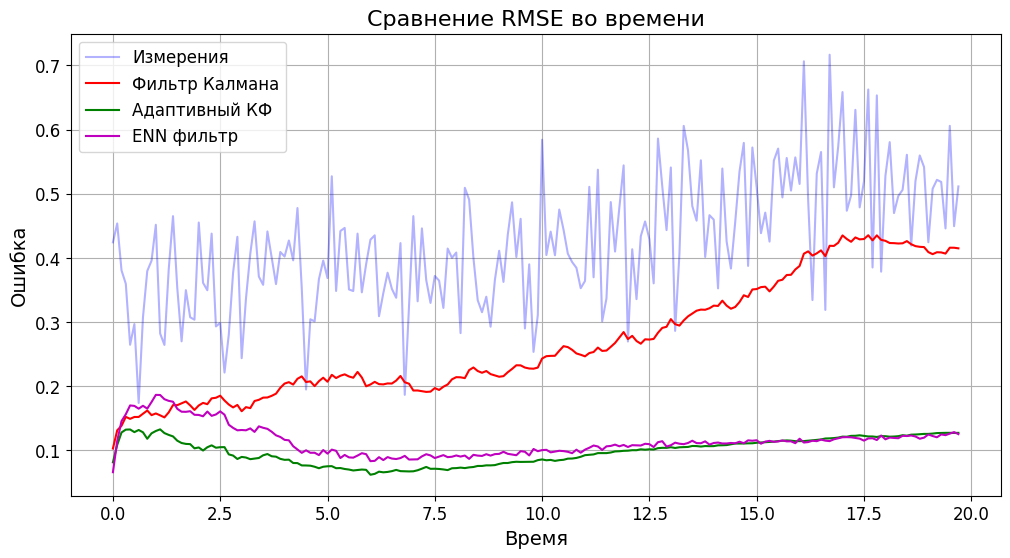

In [ ]:
# 5. Тест

x_sage_husa2 = np.zeros((all_seq_s2, N, dim_X))
for i in range(all_seq_s2):
  xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge, alpha=best_b, Ksi_U = S*6)
  #xf = Sage_Husa_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new, b=best_b)
  x_sage_husa2[i] = xf

x_kalman2 = np.zeros((all_seq_s2, N, dim_X))
for i in range(all_seq_s2):
  xf = Kalman_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new, Ksi_U=S*6, Ge=Ge)
  x_kalman2[i] = xf

y_mc2 = y_measure2[:, 1:-1, 0]
y_ec11 = x_sage_husa2[:, 1:-1, num_Xi]
y_ec22 = x_sage_husa2[:, :-2, num_Xi]
y_ec33 = x_sage_husa2[:, 2:, num_Xi]
y_c2 = x_true2[:, 2:, num_Xi]

# Объединение в массив (batch, 300, 3)
X_test2 = np.stack([y_mc2, y_ec11, y_ec22], axis=2)
y_c_ec2 = np.stack([y_c2, y_ec33], axis=2)
e_test2 = y_c_ec2[:,:,0]-y_c_ec2[:,:,1]
e_test2 = e_test2[:, :, np.newaxis]  # Форма (n, m, 1)
print(e_test2.shape)

pred_test2 = model.predict(X_test2)
y_enn_test, rmse_row1, rmse_row2 = result_enn_rmse(x_true2, x_noise2, y_measure2, x_sage_husa2, pred_test2, y_c_ec2, Q_new, R_new,
                                                   num_xi = num_Xi, Ksi_U=S*6, Ge=Ge, fl_train=False)

meas_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], y_measure2[:, 2:, 0])
kalman_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], x_kalman2[:, 2:, num_Xi])
akf_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], x_sage_husa2[:, 2:, num_Xi])
enn_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], y_enn_test)

# График
dt = 0.1
time = np.arange(N-2) * dt
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, kalman_rmse_time, 'r', label='Фильтр Калмана')
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.plot(time, enn_rmse_time, 'm', label='ENN фильтр')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

plt.savefig('rmse_plot.jpg', dpi=150, bbox_inches='tight')  # JPEG формат

plt.show()

In [ ]:
files.download('rmse_plot.jpg')

##   Гиперпараметры

In [ ]:
from itertools import product
from copy import deepcopy
import torch.optim as optim
import itertools

In [ ]:
class SequenceRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(SequenceRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                         batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)  # Каждый шаг → 1 число

    def forward(self, x):
        # x shape: (batch_size, 300, 3)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)  # out shape: (batch_size, 300, hidden_size)
        out = self.fc(out)  # shape: (batch_size, 300, 1)
        return out
    def predict(self, x):
        # Переводим модель в режим оценки
        self.eval()

        # Автоматическое преобразование входных данных
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)

        # Добавляем размерность батча если нужно
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # Вычисление предсказания без вычисления градиентов
        with torch.no_grad():
            prediction = self.forward(x)

        return prediction.squeeze().numpy()  # Возвращаем numpy array

In [ ]:
# Параметры для перебора
all_params = {
    'hidden_size': [12, 64],
    'lr': [0.01, 0.001],
    'optimizer': ['Adam', 'NAdam', 'RMSProp']
}

# Генерация данных (замените на свои реальные данные)
input_size = 3
num_layers = 1

# Для сохранения результатов
results = []
best_val_loss = float('inf')
best_params = None
best_model = None
patience = 100  # Для ранней остановки

for params in itertools.product(*all_params.values()):
    current_params = dict(zip(all_params.keys(), params))
    print(f"\nTraining with params: {current_params}")

    model = SequenceRNN(input_size, current_params['hidden_size'], num_layers)
    criterion = nn.MSELoss()

    # Выбор оптимизатора
    optimizers = {
        'Adam': optim.Adam,
        'NAdam': optim.NAdam,
        'RMSProp': optim.RMSprop
    }
    optimizer = optimizers[current_params['optimizer']](model.parameters(), lr=current_params['lr'])

    # Обучение с отслеживанием валидационной ошибки
    no_improve = 0
    best_epoch_loss = float('inf')

    for epoch in range(700):
        model.train()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Валидация
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_targets)

        # Проверка на улучшение
        if val_loss < best_epoch_loss:
            best_epoch_loss = val_loss
            no_improve = 0
            current_best_state = deepcopy(model.state_dict())
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}, лучший Val Loss: {best_epoch_loss:.4f}")
            break

    # Сохранение результатов для этой конфигурации
    results.append({
        'params': current_params,
        'val_loss': best_epoch_loss.item(),
        'train_loss': loss.item()
    })

    # Проверка на лучшую модель
    if best_epoch_loss < best_val_loss:
        best_val_loss = best_epoch_loss
        best_params = current_params
        best_model = current_best_state
        print(f"Новый лучший результат: Val Loss = {best_val_loss:.4f}")

# Вывод результатов
print("\nЛучшие параметры:", best_params)
print("Лучшая валидационная ошибка:", best_val_loss.item())

# Сохранение лучшей модели
torch.save({
    'model_state_dict': best_model,
    'best_params': best_params,
    'val_loss': best_val_loss
}, 'best_model_val.pth')


Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 137, лучший Val Loss: 0.0007
Новый лучший результат: Val Loss = 0.0007

Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'NAdam'}
Ранняя остановка на эпохе 160, лучший Val Loss: 0.0036

Training with params: {'hidden_size': 12, 'lr': 0.01, 'optimizer': 'RMSProp'}
Ранняя остановка на эпохе 160, лучший Val Loss: 0.0015

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 281, лучший Val Loss: 0.0022

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'NAdam'}
Ранняя остановка на эпохе 349, лучший Val Loss: 0.0018

Training with params: {'hidden_size': 12, 'lr': 0.001, 'optimizer': 'RMSProp'}
Ранняя остановка на эпохе 309, лучший Val Loss: 0.0023

Training with params: {'hidden_size': 64, 'lr': 0.01, 'optimizer': 'Adam'}
Ранняя остановка на эпохе 218, лучший Val Loss: 0.0007
Новый лучший результат: Val Lo